In [3]:
# === Standard Libraries ===
import os
import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
from scipy.stats import median_abs_deviation
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from tqdm import tqdm
import pyBigWig as pbw

# === PyTorch ===
import torch
from torch.utils.data import DataLoader

# === Tangermeme
# from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
# from tangermeme.plot import plot_logo
# from tangermeme.predict import predict
# from tangermeme.product import apply_pairwise
# from tangermeme.io import read_meme
# from tangermeme.annotate import annotate_seqlets, count_annotations
# from tangermeme.seqlet import recursive_seqlets, tfmodisco_seqlets



In [4]:
%run /home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/Common.ipynb
params.read("/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini")

['/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini']

In [5]:
import anndata as ad
import pandas as pd
import numpy as np
from genome_tools.data.anndata import read_zarr_backed
from genome_tools import GenomicInterval, VariantInterval, df_to_variant_intervals
from genome_tools.data.extractors import FastaExtractor, TabixExtractor

from vinson.utils.sequence_utils import one_hot_encode, get_iupac_char_from_alleles
from vinson.utils.helpers import replace_at
import logging

from vinson.utils.data_formatting import extract_data_from_h5
from vinson.from_config import read_configs

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]



In [6]:
import os
import sys
import random
import numpy as np
import anndata as ad
from argparse import ArgumentParser


import torch
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)
from vinson.from_config import (
    read_configs,
    variant_model_from_config,
    datamodule_from_config,
    dhs_model_from_config


)
from vinson.run import (
    set_global_seed,
    set_worker_seed,
    init_multigpu_trainer,
    fit_model,
)

torch.set_float32_matmul_precision('high')

In [83]:
var_config_path = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_24_dreamy_stonebraker/run_config.yaml'
var_checkpoint = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_24_dreamy_stonebraker/checkpoints/last.ckpt'
# var_checkpoint = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_23_zealous_panini/checkpoints/epoch=15-step=5154-val_loss=2.83.ckpt'


reg_checkpoint = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/MAR06_dima/MAR06_noise0125.ckpt'
reg_config_path = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/MAR06_dima/MAR06.yaml'

In [84]:
# variant_file = '/net/seq/data2/projects/mbrannon/vinson/3_9_dataset_35totalcount_3epoch.h5ad'
variant_file = '/net/seq/data2/projects/mbrannon/vinson/3_9_dataset_20totalcount1p5bad_3epoch.h5ad'
genotype_file = '/home/mbrannon/genotype_no_multiallelic.tsv.gz'
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

In [85]:
var_config = read_configs(var_config_path)
reg_config = read_configs(reg_config_path)
variant_model = variant_model_from_config(var_config, checkpoint_path=var_checkpoint).eval()
reg_model = dhs_model_from_config(reg_config, checkpoint_path=reg_checkpoint).eval()

device = torch.device("cpu")
variant_model.to(device)
reg_model.to(device)


SequenceEmbedModel(
  (trunk_model): LegNetTrunkEmbed(
    (stem): StemConv(
      (convs_list): ModuleList(
        (0): Conv1d(4, 24, kernel_size=(6,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(4, 24, kernel_size=(9,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(4, 24, kernel_size=(12,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(4, 24, kernel_size=(15,), stride=(1,), padding=same, bias=False)
      )
    )
    (blocks_dict): ModuleDict(
      (blc0): Sequential(
        (0): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): ResidualConcat(
          (fn): EffBlock(
            (block): Sequential(
              (0): Conv1d(96, 384, kernel_size=(1,), stride=(1,), padding=same, bias=False)
              (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU()
              (3): Conv1d(384, 384, kernel_size=(9,), stride=(1

In [86]:
from vinson.utils.data_formatting import extract_variant_data_from_anndata
from vinson.datasets.variant import VariantEmbedDataset


## reg vs variant results test

In [87]:
dhs_split = "val"
full_adata = ad.read_h5ad(variant_file)
adata_val = full_adata[
    :,
    full_adata.varm["split_data"] == dhs_split,
]

In [88]:

def to_tensor(x, device):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.to(device)
    return torch.as_tensor(x, device=device)

def predict_regular(batch, model, device):
    seq_ref = to_tensor(batch["ohe_seq_ref"], device)
    seq_alt = to_tensor(batch["ohe_seq_alt"], device)
    embed   = to_tensor(batch.get("embed"), device)

    with torch.no_grad():
        y_ref = model(
            seq=seq_ref,
            embedding=embed,
        )

        y_alt = model(
            seq=seq_alt,
            embedding=embed,
        )

    return (
        y_ref.squeeze(-1).cpu().numpy(),
        y_alt.squeeze(-1).cpu().numpy(),
    )

def predict_variant(batch, model, device):
    seq_ref = to_tensor(batch["ohe_seq_ref"], device)
    seq_alt = to_tensor(batch["ohe_seq_alt"], device)
    embed   = to_tensor(batch.get("embed"), device)

    with torch.no_grad():
        y = model(
            seq_ref=seq_ref,
            seq_alt=seq_alt,
            embed=embed,
        )

    return y.squeeze(-1).cpu().numpy()


In [89]:
all_data = extract_variant_data_from_anndata(adata_val, "epoch_1")


In [90]:
dataset = VariantEmbedDataset(
    data=all_data,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
    flip_alleles=False,
    reverse_complement=False,
        jitter=0,
    
)

val_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

In [91]:
from tqdm import tqdm

model = variant_model
model.eval()


VariantEmbedModel(
  (trunk_model): LegNetTrunkEmbed(
    (stem): StemConv(
      (convs_list): ModuleList(
        (0): Conv1d(4, 24, kernel_size=(6,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(4, 24, kernel_size=(9,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(4, 24, kernel_size=(12,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(4, 24, kernel_size=(15,), stride=(1,), padding=same, bias=False)
      )
    )
    (blocks_dict): ModuleDict(
      (blc0): Sequential(
        (0): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): ResidualConcat(
          (fn): EffBlock(
            (block): Sequential(
              (0): Conv1d(96, 384, kernel_size=(1,), stride=(1,), padding=same, bias=False)
              (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU()
              (3): Conv1d(384, 384, kernel_size=(9,), stride=(1,

In [92]:
from tqdm import tqdm
#just run 10 epoch for now
all_preds = []
all_targets = []
n=0
model = variant_model
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Running validation"):
        n+=1
        seq_ref = batch["ohe_seq_ref"].to(device)
        seq_alt = batch["ohe_seq_alt"].to(device)
        embed   = batch["embed"].to(device)

        targets = batch["lfc"].to(device)
        lfc = batch["lfc"]

        n_pos = (lfc > 0).sum().item()
        n_neg = (lfc <= 0).sum().item()
        
        print(f"Batch {n}: pos={n_pos}, neg={n_neg}")

        outputs = model(
            seq_ref=seq_ref,
            seq_alt=seq_alt,
            embed=embed,
        )

        preds = outputs.squeeze(-1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        if n==20:
            break


Running validation:   0%|          | 0/810 [00:00<?, ?it/s]

Batch 1: pos=35, neg=29


Running validation:   0%|          | 1/810 [00:03<41:36,  3.09s/it]

Batch 2: pos=33, neg=31


Running validation:   0%|          | 2/810 [00:04<26:19,  1.95s/it]

...

Running validation:   2%|▏         | 18/810 [00:23<15:41,  1.19s/it]

Batch 19: pos=37, neg=27


Running validation:   2%|▏         | 19/810 [00:24<15:34,  1.18s/it]

Batch 20: pos=35, neg=29


Running validation:   2%|▏         | 19/810 [00:26<18:37,  1.41s/it]


In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)


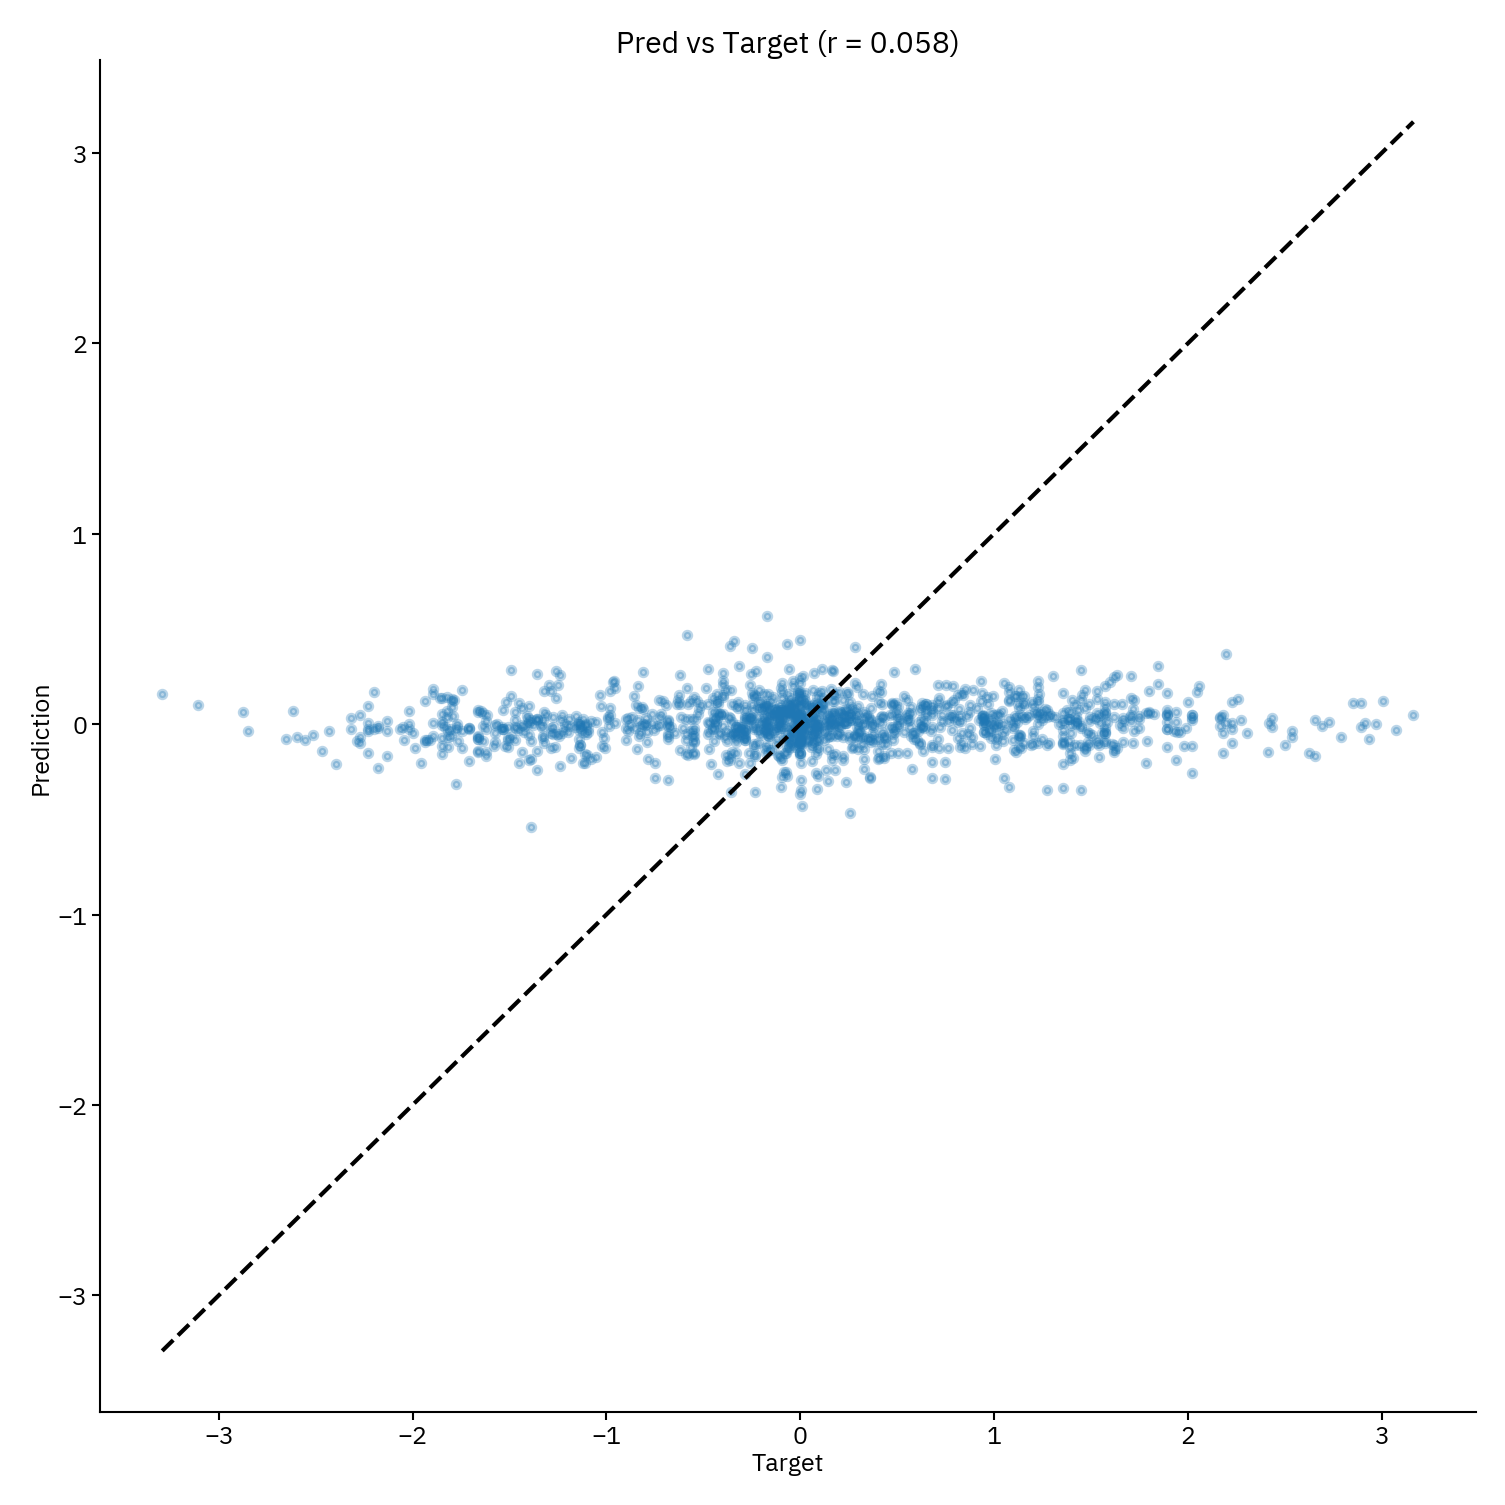

In [94]:
plt.figure(figsize=(5, 5))
plt.scatter(all_targets, all_preds, s=3, alpha=0.3)

# diagonal line
lims = [
    min(all_targets.min(), all_preds.min()),
    max(all_targets.max(), all_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_targets, all_preds)

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title(f"Pred vs Target (r = {r:.3f})")
plt.tight_layout()
plt.show()


## Predict sample id

In [22]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import anndata as ad
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load data
variants = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')

In [23]:
# =========================
# 🔹 SELECT SAMPLE INSTEAD OF RSID
# =========================
sample_id_oi = "AG72381"   # <-- CHANGE THIS

var_oi = variants[variants['sample_id'] == sample_id_oi].copy()
var_oi = var_oi.query('BAD <= 1.5')

print(f"Total variants before BAD filter: {variants[variants['sample_id'] == sample_id_oi].shape[0]}")
print(f"After BAD filter: {var_oi.shape[0]}")

# =========================
# 🔹 BUILD VAR DATAFRAME (ALL VARIANTS FOR SAMPLE)
# =========================
var_df = (
    var_oi
    .drop_duplicates('variant_id')
    .set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]
)

# 🔹 Only keep the single sample in obs
obs_df = adata.obs.loc[[sample_id_oi]].copy()

train_var_adata = ad.AnnData(X=None, var=var_df, obs=obs_df)

# =========================
# 🔹 INDEX MAPPING
# =========================
row_idx = np.zeros(len(var_oi), dtype=int)  # only ONE sample → all row_idx = 0
col_idx = var_oi['variant_id'].map(lambda x: train_var_adata.var.index.get_loc(x)).values

# =========================
# 🔹 LAYERS
# =========================
layer_cols_numeric = [
    'ref_counts', 'alt_counts', 'BAD', 'SNP_count', 'coverage', 'w', 'es','z',
    'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample', 'inverse_mse',
    'total_counts', 'group_es', 'group_es_std', 'indivs_count', 'samples_count',
    'p_differential', 'n_groups', 'group_es_var', 'mean_group_mse',
    'es_combined', 'logit_es_combined', 'fdr_group',
    'signif_max_es', 'signif_min_es', 'logit_group_es', 'full_group_std',
    'discordance_score', 'delta_es', 'delta_es_q', 'delta_logit_es'
]

layer_cols_strings = ['core_category', 'category']

# Convert numeric
var_oi[layer_cols_numeric] = var_oi[layer_cols_numeric].astype(float)

# Create sparse layers
for col in layer_cols_numeric:
    data = sp.coo_matrix(
        (var_oi[col].values, (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[col] = data

# Add string metadata per variant
for col in layer_cols_strings:
    train_var_adata.var[col] = (
        var_oi.groupby('variant_id')[col]
        .first()
        .reindex(train_var_adata.var.index)
    )

# =========================
# 🔹 ADD EMBEDDINGS / METADATA
# =========================
train_var_adata.obsm['indiv_id'] = (
    train_var_adata.obs_names
    .map(indiv_id_mapping['indiv_id'])
    .fillna('')
    .to_numpy()
    .astype(str)
)

for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

train_var_adata.obsm['motif_embeddings'] = (
    adata.obsm['motif_embeddings']
    .loc[train_var_adata.obs_names]
)

Total variants before BAD filter: 28955
After BAD filter: 28807


NameError: name 'indiv_id_mapping' is not defined

In [ ]:
# =========================
# 🔹 DATASET + LOADER
# =========================
from vinson.utils.data_formatting.readers import extract_variant_data_from_anndata
from vinson.datasets.variant import VariantEmbedDataset
from tqdm import tqdm


data = extract_variant_data_from_anndata(train_var_adata, "epoch_1")

dataset = VariantEmbedDataset(
    data=data,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
    flip_alleles=False,
    reverse_complement=False,
)

loader = DataLoader(dataset, batch_size=128, shuffle=False)

# =========================
# 🔹 MODEL PREDICTION
# =========================
model.eval()

predictions = []
actuals = []
sample_ids = []


with torch.no_grad():
    for batch in tqdm(loader):
        X_seq_ref = batch["ohe_seq_ref"]
        X_seq_alt = batch["ohe_seq_alt"]
        X_embed = batch["embed"]
        lfc = batch["lfc"]

        y = model(X_seq_ref, X_seq_alt, X_embed).squeeze()

        predictions.append(y)
        actuals.append(lfc)
        sample_ids.append(batch["sample_id"])

all_preds = torch.cat(predictions).cpu().numpy()
all_targets = torch.cat(actuals).cpu().numpy()

# =========================
# 🔹 PLOT
# =========================
plt.figure(figsize=(5, 5))
plt.scatter(all_targets, all_preds, s=3, alpha=0.3)

lims = [
    min(all_targets.min(), all_preds.min()),
    max(all_targets.max(), all_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_targets, all_preds)

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title(f"Sample {sample_id_oi} (r = {r:.3f})")
plt.tight_layout()
plt.show()

## copy sasha

In [ ]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix, lil_matrix, save_npz, load_npz

In [10]:
# #genotype_file = '/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz'
# genotype_file = '/net/seq/data2/projects/mbrannon/all_phased.no_ambiguous.sorted.with_header.bgz'
fasta_file = '/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa'

In [ ]:
model = variant_model
model.eval()

In [12]:
variants = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [15]:
# variants = used_results

In [16]:
variants['group_id']

0               B-cell
1               B-cell
2               B-cell
3               B-cell
4                 Lung
               ...    
48190820        T-cell
48190821       Adipose
48190822    Macrophage
48190823        T-cell
48190824        T-cell
Name: group_id, Length: 48190825, dtype: object

In [17]:
variants.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'badgroup',
       'indiv_id', 'total_counts', 'variant_id', 'group_id', 'group_es',
       'group_es_std', 'indivs_count', 'samples_count', 'p_differential',
       'cell_selective', 'n_groups', 'group_es_var', 'mean_group_mse',
       'es_combined', 'overall_imbalanced', 'logit_es_combined', 'fdr_group',
       'signif_max_es', 'signif_min_es', 'concordant', 'discordant',
       'logit_group_es', 'category', 'core_category', 'med_num_samples',
       'full_group_std', 'z', 'signif_z', 'max_z', 'min_z', 'min_abs_z',
       'discordance_score', 'max_z_score', 

In [13]:
import anndata as ad
from argparse import ArgumentParser

# from dnase_legnet.utils import AUC_callback,Pearsonr_callback, generate_name, read_configs_siamese

import torch
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)

from vinson.utils.helpers import save_config, generate_run_name
from vinson.run import set_global_seed,set_worker_seed,init_multigpu_trainer,fit_model
from vinson.from_config import read_configs,datamodule_from_config,variant_model_from_config

indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')


In [146]:
variants = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [19]:
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')


KeyboardInterrupt



In [190]:
#filter variants by rsid then convert to anndata
rsid = 'rs259099'
var_oi=variants[variants['ID']==rsid]

In [191]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Step 1: variants at coverage >= 20
# var_20 = variants.query('coverage >= 20')

# # Step 2: variants at coverage >= 35
# var_35 = variants.query('coverage >= 35')

# # Step 3: count per group
# count_20 = var_20['group_id'].value_counts()
# count_35 = var_35['group_id'].value_counts()

# # Step 4: compute how many were filtered out
# filtered_out = count_20.subtract(count_35, fill_value=0)

# # Step 5: sort and plot
# filtered_out = filtered_out.sort_values(ascending=False)

# plt.figure(figsize=(10,5))
# filtered_out.plot(kind='bar', color='salmon')
# plt.ylabel('Number of variants filtered out')
# plt.xlabel('Group ID')
# plt.title('Variants filtered out when going from coverage >=20 to >=35')
# plt.xticks(rotation=45, ha='right')
# plt.show()

In [192]:
var_oi = var_oi.query('coverage >= 10')

In [193]:
var_oi.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'badgroup',
       'indiv_id', 'total_counts', 'variant_id', 'group_id', 'group_es',
       'group_es_std', 'indivs_count', 'samples_count', 'p_differential',
       'cell_selective', 'n_groups', 'group_es_var', 'mean_group_mse',
       'es_combined', 'overall_imbalanced', 'logit_es_combined', 'fdr_group',
       'signif_max_es', 'signif_min_es', 'concordant', 'discordant',
       'logit_group_es', 'category', 'core_category', 'med_num_samples',
       'full_group_std', 'z', 'signif_z', 'max_z', 'min_z', 'min_abs_z',
       'discordance_score', 'max_z_score', 

In [194]:
var_oi = var_oi.query('BAD <= 1.5')

In [195]:
var_oi

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,max_es_group_std,max_es,min_es_group_std,min_es,delta_es,delta_es_std,delta_es_q,delta_logit_es,med_std_group,abs_logit_group_es
36986146,chr5,79795944,79795945,rs259099,G,C,0,13,AG95472,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986147,chr5,79795944,79795945,rs259099,G,C,0,15,AG95406,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986148,chr5,79795944,79795945,rs259099,G,C,0,17,AG95470,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986149,chr5,79795944,79795945,rs259099,G,C,0,21,AG95424,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986150,chr5,79795944,79795945,rs259099,G,C,0,22,AG95410,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36986338,chr5,79795944,79795945,rs259099,G,C,9,14,AG80318,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986339,chr5,79795944,79795945,rs259099,G,C,9,15,AG81601,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986340,chr5,79795944,79795945,rs259099,G,C,9,16,AG80161,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,0.509816
36986341,chr5,79795944,79795945,rs259099,G,C,9,23,AG72732,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,2.025107


In [196]:
var_df = var_oi.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]

In [197]:
train_var_adata = ad.AnnData(X=None, var=var_df, obs=adata.obs)
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 1
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', 'treatm

In [198]:
row_idx = var_oi['sample_id'].map(lambda x: train_var_adata.obs.index.get_loc(x))
col_idx = var_oi['variant_id'].map(lambda x: train_var_adata.var.index.get_loc(x))

In [199]:
import numpy as np

# Numeric columns
layer_cols_numeric = [
    'ref_counts', 'alt_counts',  'BAD', 'SNP_count', 'coverage', 'w', 'es','z',
    'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample', 'inverse_mse',
    'total_counts', 'group_es', 'group_es_std', 'indivs_count', 'samples_count',
    'p_differential', 'n_groups', 'group_es_var', 'mean_group_mse',
    'es_combined', 'logit_es_combined', 'fdr_group',
    'signif_max_es', 'signif_min_es', 'logit_group_es', 'full_group_std', 'discordance_score',
    'delta_es', 'delta_es_q', 'delta_logit_es'
]

# String columns
layer_cols_strings = ['core_category', 'category']

# Convert numeric columns to float
var_oi[layer_cols_numeric] = var_oi[layer_cols_numeric].astype(float)


In [200]:


for col in layer_cols_numeric:
    data = sp.coo_matrix(
        (var_oi[col].values, (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[col] = data

# Add string columns to var (per-variant metadata)
for col in ['core_category', 'category']:
    # Use the first occurrence per variant_id
    train_var_adata.var[col] = var_oi.groupby('variant_id')[col].first().reindex(train_var_adata.var.index)

In [201]:
train_var_adata.obsm['indiv_id'] = train_var_adata.obs_names.map(indiv_id_mapping['indiv_id']).fillna('').to_numpy().astype(str)

In [202]:
for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

In [203]:
train_var_adata.obsm['motif_embeddings'] = adata.obsm['motif_embeddings'].loc[train_var_adata.obs_names]

In [204]:
#save
# train_var_adata.write_h5ad("/home/mbrannon/tmp/3_2_trainann.h5ad")


In [205]:
# variants[variants['ID']=='rs75326860']

In [206]:
from torch.utils.data import DataLoader
from vinson.utils.data_formatting.readers import extract_variant_data_from_anndata

data = extract_variant_data_from_anndata(train_var_adata, "epoch_1")

In [207]:
 data

VinsonData with keys: ['chrom', 'pos', 'ref', 'alt', 'sample_id', 'ref_counts', 'total_counts', 'BAD', 'logit_es', 'indiv_id']. Encoded columns: ['sample_id', 'chrom', 'ref', 'alt', 'indiv_id'].

In [208]:
# 4️⃣ Wrap in VariantEmbedDataset
from vinson.datasets.variant import VariantEmbedDataset

dataset = VariantEmbedDataset(
    data=data,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
    flip_alleles=False,
    reverse_complement=False,
)

# 5️⃣ Create DataLoader
loader = DataLoader(dataset, batch_size=128, shuffle=False)


In [209]:
model.eval()

predictions = []
actuals = []

sample_ids = []


with torch.no_grad():
    for batch in loader:
        X_seq_ref = batch["ohe_seq_ref"]
        X_seq_alt = batch["ohe_seq_alt"]
        X_embed = batch["embed"]
        lfc = batch["lfc"]

        y = model(X_seq_ref, X_seq_alt, X_embed).squeeze()

        predictions.append(y)
        actuals.append(lfc)

        sample_ids.append(batch["sample_id"])


In [210]:
predictions = torch.cat(predictions).cpu().numpy()
actuals = torch.cat(actuals).cpu().numpy()

In [211]:
predictions.shape

(192,)

In [212]:
# Flatten batch lists
sample_ids_flat = [s for batch in sample_ids for s in batch]

In [213]:
len(sample_ids_flat)

192

In [214]:
pred_dict = dict(zip(sample_ids_flat, predictions))

In [215]:
var_oi

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,max_es_group_std,max_es,min_es_group_std,min_es,delta_es,delta_es_std,delta_es_q,delta_logit_es,med_std_group,abs_logit_group_es
36986146,chr5,79795944,79795945,rs259099,G,C,0.0,13.0,AG95472,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986147,chr5,79795944,79795945,rs259099,G,C,0.0,15.0,AG95406,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986148,chr5,79795944,79795945,rs259099,G,C,0.0,17.0,AG95470,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986149,chr5,79795944,79795945,rs259099,G,C,0.0,21.0,AG95424,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986150,chr5,79795944,79795945,rs259099,G,C,0.0,22.0,AG95410,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36986338,chr5,79795944,79795945,rs259099,G,C,9.0,14.0,AG80318,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986339,chr5,79795944,79795945,rs259099,G,C,9.0,15.0,AG81601,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN
36986340,chr5,79795944,79795945,rs259099,G,C,9.0,16.0,AG80161,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,0.509816
36986341,chr5,79795944,79795945,rs259099,G,C,9.0,23.0,AG72732,0.21926,...,0.375552,0.575874,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,2.025107


In [216]:
var_oi['predicted_es'] = var_oi['sample_id'].map(pred_dict)

actual_dict = dict(zip(sample_ids_flat, actuals))
var_oi['lfc'] = var_oi['sample_id'].map(actual_dict)

In [217]:
v_df = var_oi

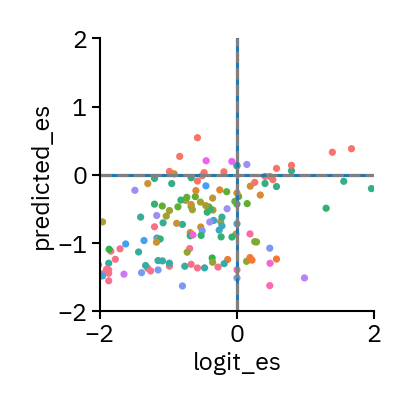

In [218]:
sns.scatterplot(data=v_df, y='predicted_es', x='logit_es', hue='group_id',legend=False, s=3, lw=0)
plt.axvline(0)
plt.axhline(0)
plt.ylim(-2, 2)
plt.xlim(-2, 2)
plt.axvline(0, color='gray', linestyle='--')
plt.axhline(0, color='gray', linestyle='--')
plt.ylim(-2, 2)
plt.xlim(-2, 2)
plt.show()

In [219]:
vtemp = var_oi[var_oi['group_id']=='Fetal life support']
vtemp[['#chr','start','end','ID','ref','alt','ref_counts','alt_counts','sample_id','logit_es','lfc','predicted_es']]

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,logit_es,lfc,predicted_es
36986202,chr5,79795944,79795945,rs259099,G,C,2.0,13.0,AG72733,-2.083300,-1.444034,-1.186251
36986221,chr5,79795944,79795945,rs259099,G,C,29.0,99.0,AG72794,-1.166088,-0.808271,-0.925776
36986230,chr5,79795944,79795945,rs259099,G,C,3.0,16.0,AG80554,-2.358687,-1.634917,-1.119438
36986245,chr5,79795944,79795945,rs259099,G,C,4.0,11.0,AG80177,-1.433061,-0.993322,-1.129699
36986247,chr5,79795944,79795945,rs259099,G,C,4.0,15.0,AG80428,-1.868529,-1.295166,-1.294041
36986257,chr5,79795944,79795945,rs259099,G,C,4.0,38.0,AG80097,-3.146589,-2.181049,-1.236775
36986268,chr5,79795944,79795945,rs259099,G,C,4.0,9.0,AG80343,-1.149941,-0.797078,-1.255928
36986292,chr5,79795944,79795945,rs259099,G,C,6.0,23.0,AG72726,-1.330865,-0.922485,-1.327906
36986329,chr5,79795944,79795945,rs259099,G,C,8.0,24.0,AG72734,-0.985130,-0.682840,-1.293508
36986341,chr5,79795944,79795945,rs259099,G,C,9.0,23.0,AG72732,-0.760219,-0.526943,-1.339066


In [220]:
rsid

'rs259099'

In [221]:
melt_var_df = v_df.melt(id_vars=[x for x in v_df.columns if x not in ('predicted_es', 'lfc')])
hue_order = v_df.groupby('group_id')['predicted_es'].agg('median').sort_values().index

In [222]:
melt_var_df

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,min_es_group_std,min_es,delta_es,delta_es_std,delta_es_q,delta_logit_es,med_std_group,abs_logit_group_es,variable,value
0,chr5,79795944,79795945,rs259099,G,C,0.0,13.0,AG95472,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN,predicted_es,-1.314638
1,chr5,79795944,79795945,rs259099,G,C,0.0,15.0,AG95406,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN,predicted_es,-1.161055
2,chr5,79795944,79795945,rs259099,G,C,0.0,17.0,AG95470,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN,predicted_es,-1.354809
3,chr5,79795944,79795945,rs259099,G,C,0.0,21.0,AG95424,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN,predicted_es,-1.329697
4,chr5,79795944,79795945,rs259099,G,C,0.0,22.0,AG95410,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN,predicted_es,-1.326545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,chr5,79795944,79795945,rs259099,G,C,9.0,14.0,AG80318,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN,lfc,-0.128714
380,chr5,79795944,79795945,rs259099,G,C,9.0,15.0,AG81601,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,NaN,lfc,-0.502629
381,chr5,79795944,79795945,rs259099,G,C,9.0,16.0,AG80161,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,0.509816,lfc,-0.566028
382,chr5,79795944,79795945,rs259099,G,C,9.0,23.0,AG72732,0.21926,...,0.286508,0.100718,0.475156,0.472363,1.005915,3.497525,0.114107,2.025107,lfc,-0.526943


In [223]:
# Remove rows with missing values
melt_var_df = melt_var_df.dropna(subset=["value", "group_id"])

# Remove unused categorical levels (THIS is the key)
melt_var_df["group_id"] = melt_var_df["group_id"].astype("category")
melt_var_df["group_id"] = melt_var_df["group_id"].cat.remove_unused_categories()


In [224]:
hue_order = (
    melt_var_df
    .query("variable == 'predicted_es'")
    .groupby("group_id")["value"]
    .median()
    .sort_values()
    .index
)


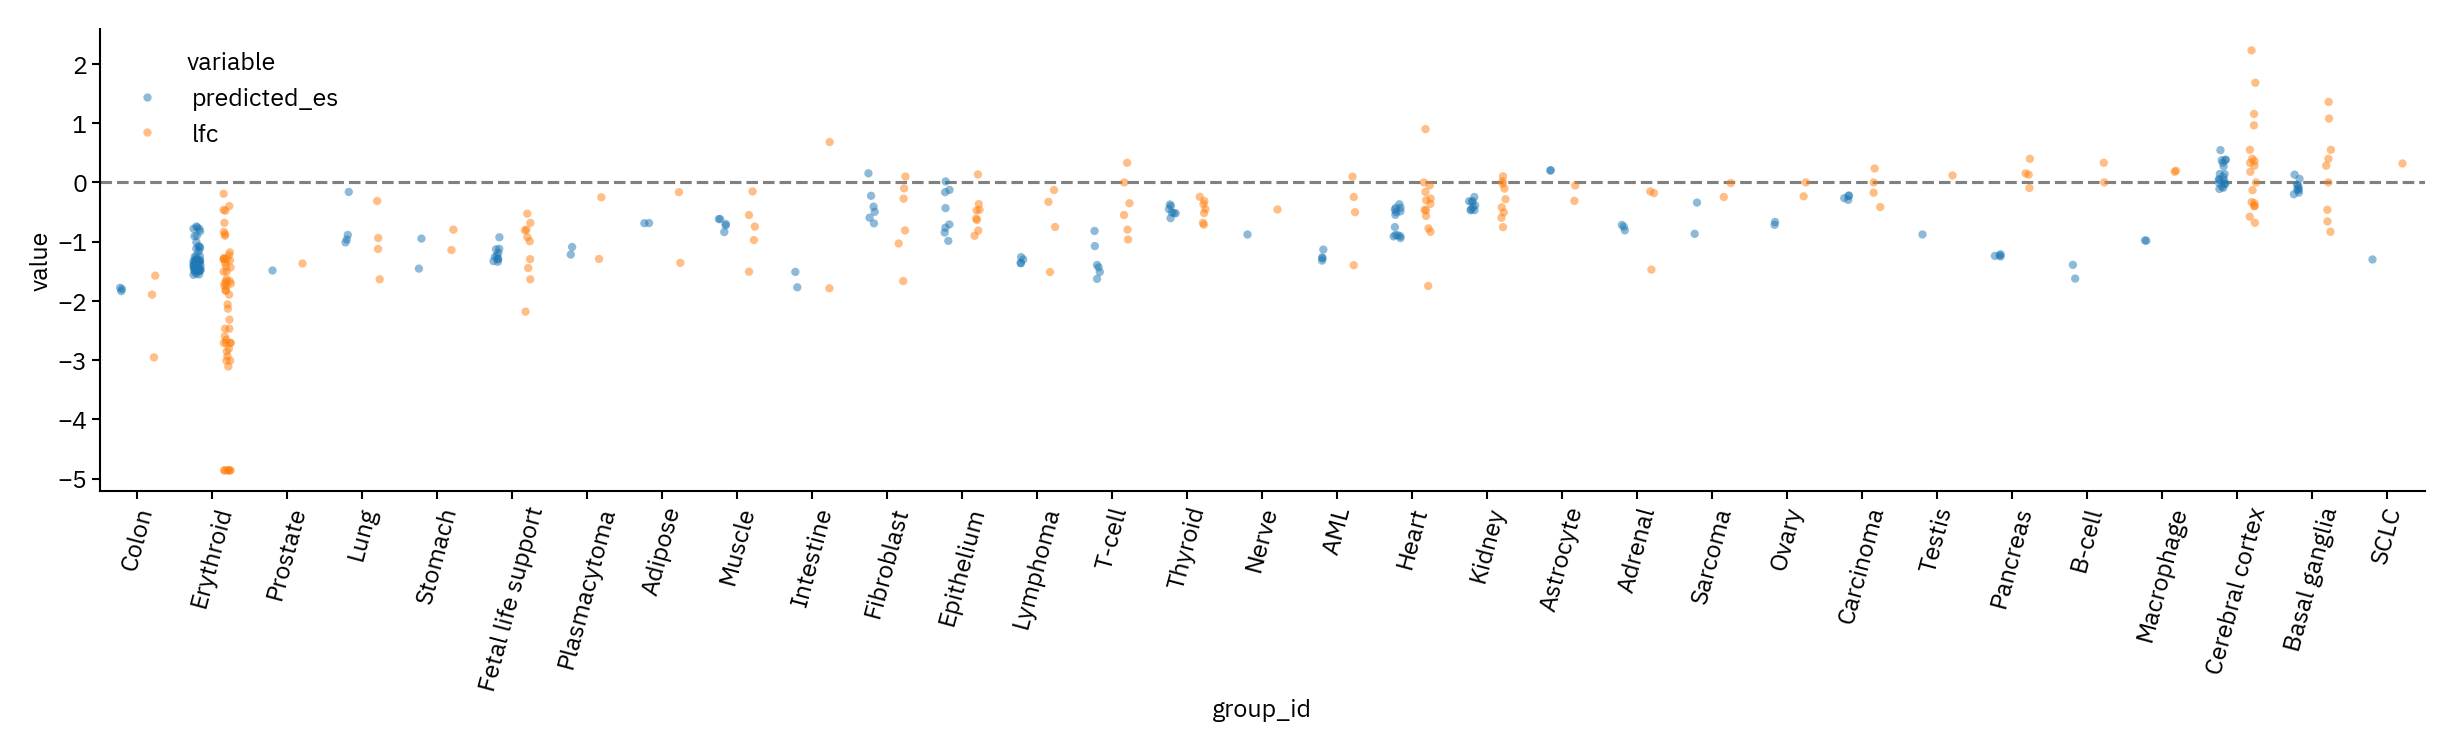

In [225]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute median logit_es per group
median_logit = melt_var_df[melt_var_df['variable'] == 'lfc'].groupby('group_id')['value'].median()

# Sort group_ids by median
hue_order_sorted = median_logit.sort_values().index.tolist()

# Plot
fig, ax = plt.subplots(figsize=(10, 2))

sns.stripplot(
    data=melt_var_df,
    x="group_id",
    y="value",
    hue="variable",
    ax=ax,
    order=hue_order_sorted,  # use sorted order
    s=2,
    alpha=0.5,
    dodge=True
)

ax.axhline(0, color="gray", ls="--")
ax.set_xticklabels(ax.get_xticklabels(), rotation=75)

# Optional: set y-axis range
# ax.set_ylim(-2, 3)

plt.show()

In [ ]:
#predicitons
srun --partition=hpcg-test --mem=200G python /home/mbrannon/.local/src/vinson/predict_variant.py \
        /net/seq/data2/projects/mbrannon/vinson/3_9_dataset_20totalcount_3epoch.h5ad \
        /net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
        /net/seq/data2/projects/mbrannon/variant_model_test/2026_03_19_determined_mayer/checkpoints/epoch=15-step=5560-val_loss=2.91.ckpt \
        /net/seq/data2/projects/mbrannon/variant_model_test/2026_03_19_determined_mayer/run_config.yaml \
        --genotype_file /home/mbrannon/genotype_no_multiallelic.tsv.gz \
        --num_workers 4 \
        --batch_size 256 \
        --output /net/seq/data2/projects/mbrannon/vinson/3_20_predict.np

### Shap

In [209]:
rsid

'rs10151094'

### read files

In [97]:
%run /home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/Common.ipynb
params.read("/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini")

['/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini']

In [123]:
per_variant_results=variants

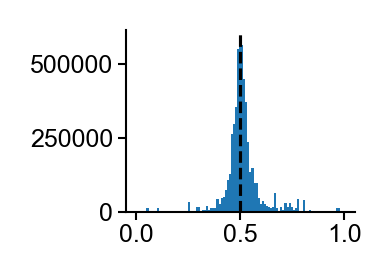

In [124]:
plt.figure(figsize=array2inch(2.5, 2))
plt.hist(per_variant_results['es_combined'], bins=101, lw=0, range=(0, 1))
plt.axvline(x=0.5, ls='--', color='k')
plt.show()

<Axes: xlabel='p_differential', ylabel='Count'>

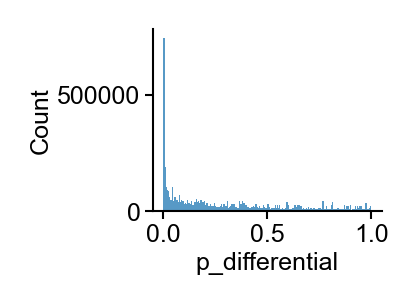

In [125]:
plt.figure(figsize=array2inch(2.5, 2))
sns.histplot(per_variant_results['p_differential'], lw=0)

### categories

In [15]:
per_variant_results = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [16]:
per_variant_results['category'].value_counts()

category
not_imbalanced            41544764
not_cell_selective         4079517
concordant_and_overall     1032277
discordant                  759515
discordant_and_overall      502312
concordant                  269386
weak_cell_selective           3054
Name: count, dtype: int64

In [20]:
adata = ad.read_h5ad(variant_file)

# vinson_data = extract_variant_data_from_anndata(
#     train_adata=adata,
#     suffix='epoch_1',
# )

# dataset = VariantEmbedDataset(
#     data=vinson_data,
#     fasta_file=fasta_file,
#     genotype_file=genotype_file,
#     flip_alleles=False,
#     reverse_complement=False,
#         jitter=0,
    
# )

# val_loader = DataLoader(
#     dataset,
#     batch_size=64,
#     shuffle=False,
#     num_workers=1,
#     pin_memory=True,
#     drop_last=False,
# )

# records = []

# for i in range(len(dataset)):
#     item = dataset[i]

#     records.append({
#         "ref_counts": item["ref_counts"],
#         "total_counts": item["total_counts"],
#         "sample_id": item["sample_id"],
#         "chrom": item["chrom"],
#         "pos": item["pos"],
#         "bad_score": item["bad_score"],
#         "lfc": item["lfc"],
#     })

# eval_dataset = pd.DataFrame(records)

# y_hat_all = np.load("/net/seq/data2/projects/mbrannon/vinson/3_20_predict.np.npy")

# eval_dataset["pred_lfc"] = y_hat_all


In [21]:
adata

AnnData object with n_obs × n_vars = 4159 × 1428944
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [78]:
# Make sure chrom and pos are strings
eval_dataset["chrom"] = eval_dataset["chrom"].astype(str)
eval_dataset["pos_str"] = eval_dataset["pos"].astype(int).astype(str)  # int, not float

variant_keys = adata.var["#chr"].astype(str) + ":" + adata.var["end"].astype(int).astype(str)
variant_to_idx = {k: i for i, k in enumerate(variant_keys)}

eval_keys = eval_dataset["chrom"] + ":" + eval_dataset["pos_str"]
var_idx = eval_keys.map(variant_to_idx).values

# Check missing mappings
print(np.isnan(var_idx).sum(), "missing variant mappings")

784384 missing variant mappings


In [54]:
print(type(vinson_data))
print(vinson_data.data.keys())

<class 'vinson.utils.data_formatting.container.VinsonData'>
dict_keys(['chrom', 'pos', 'ref', 'alt', 'sample_id', 'ref_counts', 'total_counts', 'BAD', 'logit_es', 'indiv_id'])


In [43]:
adata

AnnData object with n_obs × n_vars = 4159 × 1428944
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [44]:
import numpy as np
adata = ad.read_h5ad(variant_file)

# vinson_data = extract_variant_data_from_anndata(
#     train_adata=adata,
#     suffix='epoch_1',
# )
# eval_dataset = pd.DataFrame({
#     "ref_counts": vinson_data.data["ref_counts"],
#     "total_counts": vinson_data.data["total_counts"],
#     "sample_id": vinson_data.data["sample_id"],
#     "chrom": vinson_data.data["chrom"],
#     "pos": vinson_data.data["pos"],
#     "BAD": vinson_data.data["BAD"],
#     "lfc": vinson_data.data["logit_es"]* np.log(2),
# })
from vinson.utils.data_formatting.readers import get_examples_indices_from_layer

ref_layer = adata.layers["ref_counts.epoch_1"]
row_idx, col_idx = get_examples_indices_from_layer(
    adata.layers["ref_counts.epoch_1"].tocoo()
)
# row_idx, col_idx = get_examples_indices_from_layer(ref_layer)
eval_dataset = pd.DataFrame({
    "ref_counts": adata.layers["ref_counts.epoch_1"].data,
    "total_counts": adata.layers["total_counts.epoch_1"].data,
    "BAD": adata.layers["BAD.epoch_1"].data,
    "lfc": adata.layers["logit_es.epoch_1"].data * np.log(2),
    "sample_id": adata.obs_names[row_idx],
    "chrom": adata.var["#chr"].values[col_idx],
    "pos": adata.var["end"].values[col_idx],
    "core_category": adata.var["core_category"].values[col_idx],
    "category": adata.var["category"].values[col_idx],
    "group_id": adata.obs["extended_annotation"].values[row_idx],
})


y_hat_all = np.load("/net/seq/data2/projects/mbrannon/vinson/3_20_predict.np.npy")

eval_dataset["pred_lfc"] = y_hat_all


In [45]:
eval_dataset

,ref_counts,total_counts,BAD,lfc,sample_id,chrom,pos,core_category,category,group_id,pred_lfc
0,15.0,32.0,1.0,-0.123233,AG10031,chr1,23559582,not_imbalanced,not_imbalanced,CML,-0.414186
1,17.0,32.0,1.0,0.123233,AG10031,chr1,30719457,not_imbalanced,not_imbalanced,CML,0.128996
2,17.0,31.0,2.0,-0.339548,AG10031,chr1,146037986,not_imbalanced,not_imbalanced,CML,0.062472
3,9.0,50.0,3.0,-0.411124,AG10031,chr1,204507123,not_imbalanced,not_imbalanced,CML,-0.037123
4,27.0,46.0,2.5,-0.554565,AG10031,chr1,234499246,not_cell_selective,not_cell_selective,CML,-0.165226
...,...,...,...,...,...,...,...,...,...,...,...
784379,12.0,27.0,1.0,-0.219683,AG4009,chr17,47279416,not_cell_selective,not_cell_selective,Thyroid,-0.318387
784380,13.0,23.0,1.0,0.258283,AG4009,chr3,143001506,not_imbalanced,not_imbalanced,Thyroid,0.171577
784381,13.0,25.0,1.0,0.078810,AG4009,chr5,75337189,not_imbalanced,not_imbalanced,Thyroid,-0.002990
784382,9.0,22.0,1.0,-0.361942,AG4009,chr5,172771497,not_imbalanced,not_imbalanced,Thyroid,-0.113328


In [46]:
sample_to_idx = {k: i for i, k in enumerate(adata.obs_names)}

# create a unique key for variants
var_keys = adata.var["#chr"].astype(str) + ":" + adata.var["start"].astype(str)
variant_to_idx = {k: i for i, k in enumerate(var_keys)}

In [47]:
eval_keys = (
    eval_dataset["chrom"].astype(str)
    + ":"
    + (eval_dataset["pos"] - 1).astype(str)
)
obs_idx = eval_dataset["sample_id"].map(sample_to_idx).values
var_idx = eval_keys.map(variant_to_idx).values

In [48]:
print(np.isnan(obs_idx).sum(), "missing sample mappings")
print(np.isnan(var_idx).sum(), "missing variant mappings")

0 missing sample mappings
0 missing variant mappings


In [49]:
epoch = "epoch_1"

layer_names = [
    k for k in adata.layers.keys()
    if k.endswith(f".{epoch}")
]

for layer_name in layer_names:
    col_name = layer_name.replace(f".{epoch}", "")  # cleaner column name
    
    layer = adata.layers[layer_name]
    
    try:
        eval_dataset[col_name] = layer[obs_idx, var_idx].A1
    except AttributeError:
        eval_dataset[col_name] = layer[obs_idx, var_idx].toarray().ravel()

In [50]:
# Make a subset where BAD <= 1.5
subset_df = eval_dataset[eval_dataset["BAD"] <= 1.5].copy()

# Check the first few rows
print(subset_df.head())
print(f"Original rows: {len(eval_dataset)}, Filtered rows: {len(subset_df)}")

    ref_counts  total_counts  BAD       lfc sample_id chrom        pos  \
0         15.0          32.0  1.0 -0.123233   AG10031  chr1   23559582   
1         17.0          32.0  1.0  0.123233   AG10031  chr1   30719457   
26         8.0          23.0  1.0 -0.618304   AG10032  chr1  110407655   
35        11.0          21.0  1.0  0.093842   AG10032  chr2  174248784   
40        17.0          39.0  1.5  0.052453   AG10032  chr6  144095731   

         core_category            category group_id  ...  min_pval  n_groups  \
0       not_imbalanced      not_imbalanced      CML  ...  0.860050       NaN   
1       not_imbalanced      not_imbalanced      CML  ...  0.860050       NaN   
26      not_imbalanced      not_imbalanced      CML  ...  0.210040       NaN   
35  not_cell_selective  not_cell_selective      CML  ...  1.000000       NaN   
40      not_imbalanced      not_imbalanced      CML  ...  0.902548       NaN   

    p_differential  pval_alt  pval_ref  samples_count  signif_max_es  \
0 

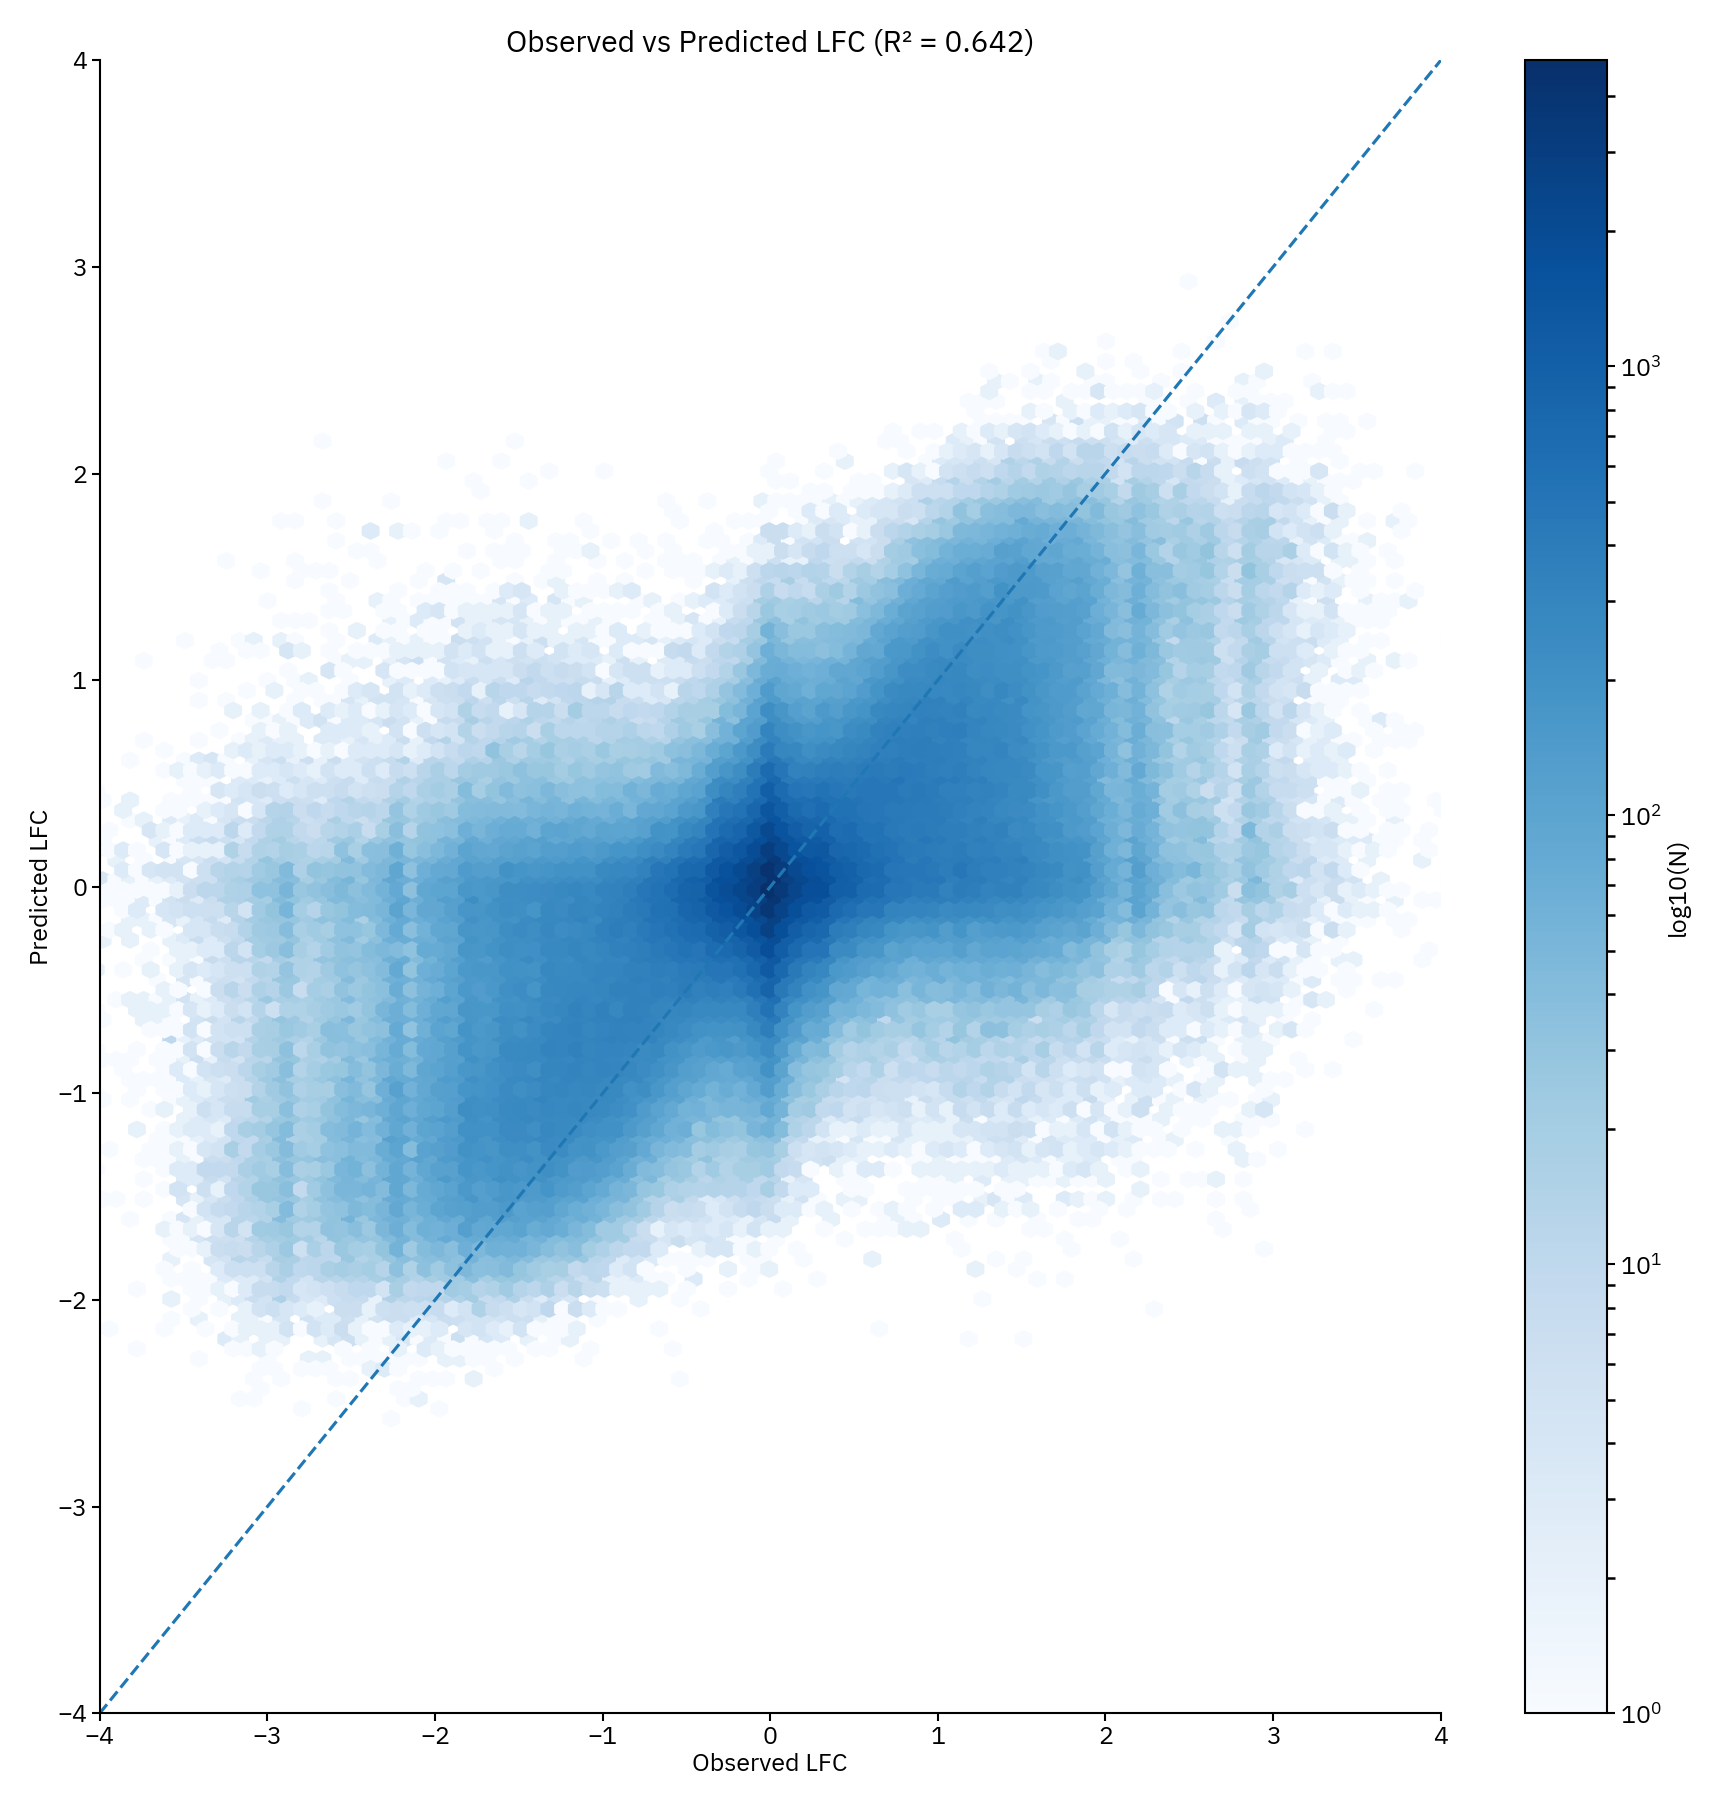

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# --- filter range ---
df = subset_df

x = df["lfc"].values
y = df["pred_lfc"].values

r, _ = pearsonr(x, y)


# --- hexbin plot ---
plt.figure(figsize=(6, 6))

hb = plt.hexbin(
    x, y,
    gridsize=100,
    bins='log',
    cmap='Blues' 
)

plt.colorbar(label="log10(N)")

# identity line
plt.plot([-4, 4], [-4, 4], linestyle='--')

plt.xlim(-4, 4)
plt.ylim(-4, 4)

plt.xlabel("Observed LFC")
plt.ylabel("Predicted LFC")
plt.title(f"Observed vs Predicted LFC (R² = {r:.3f})")

plt.tight_layout()
plt.show()

In [106]:
df

,ref_counts,total_counts,BAD,lfc,sample_id,chrom,pos,core_category,category,pred_lfc,...,min_pval,n_groups,p_differential,pval_alt,pval_ref,samples_count,signif_max_es,signif_min_es,w,z
0,15.0,32.0,1.0,-0.123233,AG10031,chr1,23559582,not_imbalanced,not_imbalanced,-0.414186,...,0.860050,NaN,NaN,0.430025,0.701693,NaN,NaN,NaN,0.500000,NaN
1,17.0,32.0,1.0,0.123233,AG10031,chr1,30719457,not_imbalanced,not_imbalanced,0.128996,...,0.860050,NaN,NaN,0.701693,0.430025,NaN,NaN,NaN,0.500000,NaN
26,8.0,23.0,1.0,-0.618304,AG10032,chr1,110407655,not_imbalanced,not_imbalanced,-0.132041,...,0.210040,NaN,NaN,0.105020,0.953430,NaN,NaN,NaN,0.500000,NaN
35,11.0,21.0,1.0,0.093842,AG10032,chr2,174248784,not_cell_selective,not_cell_selective,0.142314,...,1.000000,NaN,NaN,0.668188,0.500000,NaN,NaN,NaN,0.500000,NaN
40,17.0,39.0,1.5,0.052453,AG10032,chr6,144095731,not_imbalanced,not_imbalanced,-0.466876,...,0.902548,NaN,NaN,0.652440,0.451274,NaN,NaN,NaN,0.116364,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784379,12.0,27.0,1.0,-0.219683,AG4009,chr17,47279416,not_cell_selective,not_cell_selective,-0.318387,...,0.701108,10.0,0.153485,0.350554,0.778966,9.0,0.5,0.5,0.500000,-0.356108
784380,13.0,23.0,1.0,0.258283,AG4009,chr3,143001506,not_imbalanced,not_imbalanced,0.171577,...,0.677639,NaN,NaN,0.797564,0.338820,NaN,NaN,NaN,0.500000,NaN
784381,13.0,25.0,1.0,0.078810,AG4009,chr5,75337189,not_imbalanced,not_imbalanced,-0.002990,...,1.000000,NaN,NaN,0.654981,0.500000,NaN,NaN,NaN,0.500000,NaN
784382,9.0,22.0,1.0,-0.361942,AG4009,chr5,172771497,not_imbalanced,not_imbalanced,-0.113328,...,0.523467,NaN,NaN,0.261734,0.856861,NaN,NaN,NaN,0.500000,NaN


In [107]:
category_colors = dict(zip(
    df['category'].cat.categories,
    [
        '#fcde9c',
        '#7ccba2',
        '#f0746e',
        '#dc3977',
        '#089099',
        '#838383',
        '#C3C3C3',
    ]
))
category_colors

{'not_cell_selective': '#fcde9c',
 'concordant_and_overall': '#7ccba2',
 'discordant_and_overall': '#f0746e',
 'discordant': '#dc3977',
 'concordant': '#089099',
 'weak_cell_selective': '#838383',
 'not_imbalanced': '#C3C3C3'}

In [112]:
per_variant_results=df

In [113]:
category_labels = dict(zip(
    per_variant_results['category'].cat.categories,
    [
        'Context independent',
        'Concordant and overall imbalanced',
        'Discordant and overall imbalanced',
        'Discordant',
        'Concordant',
        'Weak context dependent',
        'Not imbalanced',
    ]
))
category_labels

{'not_cell_selective': 'Context independent',
 'concordant_and_overall': 'Concordant and overall imbalanced',
 'discordant_and_overall': 'Discordant and overall imbalanced',
 'discordant': 'Discordant',
 'concordant': 'Concordant',
 'weak_cell_selective': 'Weak context dependent',
 'not_imbalanced': 'Not imbalanced'}

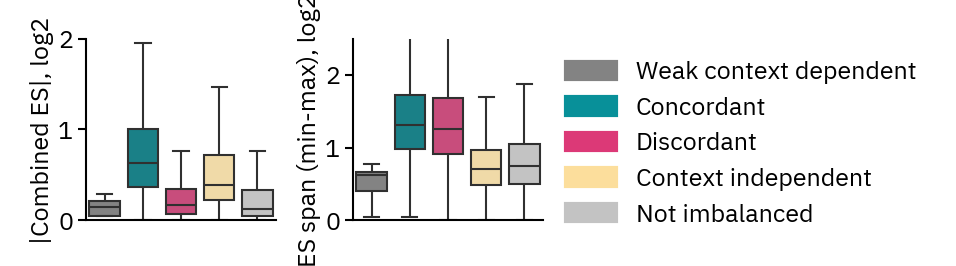

In [114]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=array2inch(5, 2))
plt.subplots_adjust(wspace=0.4)
order = per_variant_results['core_category'].cat.categories

legend_handles = [mpatches.Patch(color=category_colors[x]) for x in order]

sns.boxplot(showfliers=False, ax=ax1, legend=False, 
            data=per_variant_results, 
            x='core_category', hue='core_category', order=order,
            y=per_variant_results['logit_es_combined'].abs(), palette=category_colors,
           linewidth=0.5)
ax1.set_xticklabels([])
ax1.set_ylabel('|Combined ES|, log2')
ax1.set_xlabel('')
ax1.set_xticks([])
ax1.set_ylim(0, 2)

sns.boxplot(showfliers=False, ax=ax2, data=per_variant_results, order=order,
            x='core_category', hue='core_category', 
            y=per_variant_results['delta_logit_es'].abs(), palette=category_colors,
           linewidth=0.5)
ax2.legend(legend_handles, [category_labels[x] for x in order], title='', bbox_to_anchor=(1,1), loc='upper left',)
ax2.set_xticklabels([])
ax2.set_ylabel('ES span (min-max), log2')
ax2.set_xlabel('')
ax2.set_xticks([])
ax2.set_ylim(0, 2.5)
plt.show()

In [115]:
# Cell-selective variants pie chart

In [116]:
overall_imbalanced_cats = ['not_cell_selective', 'concordant_and_overall', 'discordant_and_overall']
cell_selective_cats = ['concordant_and_overall', 'discordant_and_overall', 'discordant', 'concordant',  'weak_cell_selective']

In [117]:
# ===============================
# Pie chart from per-variant AnnData.var
# ===============================

# Helper: percentage
def fm(x, total):
    return 0 if total == 0 else 100 * x / total

# One row = one variant → total variants
total_count = per_variant_results['variant_id'].nunique()

# Visual parameters
size = 0.07
scale = 1.5

# -------------------------------
# Count variants per category
# -------------------------------
category_counts = (
    per_variant_results
    .groupby("core_category")
    .size()
    .reset_index(name="variant_id")
    .sort_values("core_category")
    .reset_index(drop=True)
)

category_counts["percentage"] = category_counts["variant_id"].apply(
    lambda x: fm(x, total_count)
)


# -------------------------------
# Broad selective vs non-selective ring
# -------------------------------
category_counts["selective"] = category_counts["core_category"].isin(cell_selective_cats)

# group consecutive True/False segments
category_counts["selective_gr"] = (
    category_counts["selective"] != category_counts["selective"].shift()
).cumsum()

selective = (
    category_counts
    .groupby(["selective_gr", "selective"], as_index=False)
    [["variant_id", "percentage"]]
    .sum()
    .drop(columns="selective_gr")
)


# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(1.5, 1.5))

# Inner ring: fine-grained categories
patches_inner, _ = plt.pie(
    category_counts["variant_id"],
    radius=scale * (1 - size),
    wedgeprops={"linewidth": 0, "width": scale * (1 - size)},
    colors=[category_colors[x] for x in category_counts["core_category"]],
)

# Outer ring: selective vs non-selective
patches_outer, _ = plt.pie(
    selective["variant_id"],
    radius=scale,
    wedgeprops={"linewidth": 0, "width": scale * size, "edgecolor": "none"},
    colors=["#56B4E9" if x else "#FFFFFF" for x in selective["selective"]],
    labels=[
        f"Context dependent {row.variant_id} ({row.percentage:.1f}%)"
        if row.selective else ""
        for _, row in selective.iterrows()
    ],
)

# Ensure no borders
for p in patches_outer:
    p.set_edgecolor("none")
    p.set_linewidth(0)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)


# -------------------------------
# Legend
# -------------------------------
plt.legend(
    patches_inner,
    [
        f"{category_labels[row.core_category]} "
        f"{row.variant_id} ({row.percentage:.1f}%)"
        for _, row in category_counts.iterrows()
    ],
    bbox_to_anchor=(1.2, 0.7),
    frameon=False,
)

plt.show()

KeyError: 'variant_id'

In [ ]:
### plot

In [51]:
import logging
import warnings
import numpy as np
import pandas as pd
import h5py
import os

from typing import Sequence, Union
from matplotlib import gridspec
from matplotlib import transforms
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
class LoggerMixin:
    def __init__(self, logger_level: int = logging.INFO):
        self.logger = logging.getLogger(self.__class__.__name__)
        self.logger.setLevel(logger_level)

In [53]:
class PlotComponent(LoggerMixin):
    def __init__(
        self,
        width: float = 1.0,
        margins: Union[float, Sequence[float]] = 0.1,
        names_to_colors: dict = None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.width = width
        self.names_to_colors = names_to_colors

        if isinstance(margins, Sequence) and not isinstance(margins, str):
            if len(margins) != 2:
                raise ValueError("margins must be length 2")
            self.margin_left, self.margin_right = margins
        else:
            self.margin_left = self.margin_right = margins

    def plot(self, data, gs, fig, **kwargs):
        raise NotImplementedError

In [167]:
short_to_full_group_name = {
    'ALL': 'Adult tissues (Mixed)',
    'AML': 'Myeloid (CMP)',
    'APL': 'Myeloid (Erythroid)',
    'Adipose': 'Adult tissues (Heart/Muscle/Stromal)',
    'Adrenal': 'Endocrine (Adrenal)',
    'Astrocyte': 'Nervous (Fetal CNS/Eye)',
    'B-cell': 'Lymphoid (B-cells)',
    'Bladder': 'Epithelial',
    'Brain stem': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Bone': 'Adult tissues (Mixed)',
    'Bone marrow': 'Myeloid (CMP)',
    'CMP': 'Myeloid (CMP)',
    'CML': 'Myeloid (Erythroid/CMP)',
    'Carcinoma': 'Epithelial',
    'Cerebellum': 'Nervous (Cerebellum)',
    'Fetal life support': 'Fetal life support (Trophoblasts)',
    'Cerebral cortex': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Colon': 'Gastrointestinal (Adult Intestine)',
    'Dendritic': 'Myeloid (Macrophage) A',
    'Endothelium': 'Endothelial',
    'Epithelium': 'Epithelial',
    'Erythroid': 'Myeloid (Erythroid)',
    'Eye': 'Nervous (Fetal CNS/Eye)',
    'Hepatic': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Fibroblast': 'Stromal (Skin fibroblasts)',
    'Gallbladder': 'Gastrointestinal (Adult Intestine)',
    'Heart': 'Adult tissues (Heart/Muscle/Stromal)',
    'Limbic system': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Intestine': 'Gastrointestinal (Adult Intestine)',
    'Lung': 'Respiratory (Fetal)',
    'Liposarcoma': 'Adult tissues (Mixed)',
    'Pancreas': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Plasmacytoma': 'Myeloid (Erythroid/CMP)',
    'Lymphoma': 'Lymphoid (B-lymphoblasts)',
    'Macrophage': 'Myeloid (Macrophage) B',
    'Mammary adenocarcinoma': 'Epithelial',
    'Mammary ductal carcinoma': 'Epithelial',
    'Melanocyte': 'Epithelial',
    'Monocyte': 'Myeloid (Monocyte)',
    'Muscle': 'Adult tissues (Heart/Muscle/Stromal)',
    'Myeloma': 'Myeloid (Erythroid/CMP)',
    'Myoblast': 'Skeletal muscle (Fetal)',
    'Myocyte': 'Skeletal muscle (Fetal)',
    'NK-cell': 'Lymphoid (NK-cells)',
    'Nerve': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Non-SCLC': 'Lung',
    'Ovary': 'Ovary/Uterus',
    'Stroma': 'Stromal/Epithelial',
    'T-cell': 'Lymphoid (Activated T-cells)',
    'Pluripotent/Pluripotent-derived': 'Pluripotent/Pluripotent-derived',
    'Prostate': 'Epithelial',
    'Rhaboid tumor': 'Adult tissues (Mixed)',
    'SCLC': 'Lung',
    'Sarcoma': 'Adult tissues (Mixed)',
    'Spinal cord': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Uterus': 'Ovary/Uterus',
    'Ureter': 'Renal (Fetal)',
    'Testis': 'Endocrine (Adrenal)',
    'Thyroid': 'Endocrine (Thyroid)',
    'Basal ganglia': 'Nervous (Basal ganglia)',
    'Kidney': 'Epithelial (Kidney)',
    'Stomach': 'Gastrointestinal (Stomach)'
}

In [55]:
from genome_tools import GenomicInterval

In [257]:
import numpy as np
import pandas as pd
from typing import Sequence

class AnnDataVariantPreprocessor(LoggerMixin):
    """
    Preprocessor that extracts per-variant data directly from an AnnData object.
    Uses layers like 'logit_es.epoch_1', 'ref_counts.epoch_1', etc., 
    and obs/var for sample and variant info.
    """
    def __init__(self, adata, suffix="epoch_1", **kwargs):
        super().__init__(**kwargs)
        self.adata = adata
        self.suffix = suffix
    
    def filter_dfs(self, tested_df, anova_df, groups, coverage_tr):
        if groups is not None:
            anova_df = anova_df[anova_df['group_name'].isin(groups)]
            tested_df = tested_df[tested_df['group_name'].isin(groups)]

        if coverage_tr > 0:
            tested_df = tested_df.query(f'(ref_counts + alt_counts) >= {coverage_tr}')
            anova_df = anova_df[anova_df['group_name'].isin(tested_df['group_name'])]


        if tested_df.empty or anova_df.empty:
            self.logger.error(f'No data left after filtering with groups {groups} and coverage threshold {coverage_tr}')
        return tested_df, anova_df
    
    def ann_to_df(self, adata_var, suffix="epoch_1"):
        df = pd.DataFrame({
            "sample_id": adata_var.obs_names.values,
            "group_id": adata_var.obs["extended_annotation"].values,
            "variant_id": adata_var.var_names[0],
            "#chr": adata_var.var["#chr"].values[0],
            "start": adata_var.var["start"].values[0],
            "end": adata_var.var["end"].values[0],
            "ref": adata_var.var["ref"].values[0],
            "alt": adata_var.var["alt"].values[0],
            "ID": adata_var.var["ID"].values[0],
            "category":adata_var.var["category"].values[0]
        })
    
        for layer_name in adata_var.layers.keys():
            vals = adata_var.layers[layer_name]
    
            # convert sparse safely
            if sp.issparse(vals):
                vals = vals.toarray().ravel()
            else:
                vals = vals.ravel()
    
            # remove suffix (e.g. ".epoch_1")
            if layer_name.endswith(f".{suffix}"):
                clean_name = layer_name.replace(f".{suffix}", "")
            else:
                clean_name = layer_name
    
            df[clean_name] = vals
        prime = logit_es_prime(df['group_es'])
        df['logit_group_es_std'] = df['group_es_std'] * np.where(prime >0, prime, 0)
        df['logit_group_es'] = logit_es(np.clip(df['group_es'], 0, 1))
    
        return df

    def get_variant_data(self,
                         variant_id: str,
                         components: Sequence[PlotComponent],
                         sort_eval: str = 'group_es',
                         groups: list = None,
                         coverage_tr: int = 1):
        """
        Extract per-sample and per-group data for a single variant.
        Returns: components, component_data, n_samples
        """
        
        # --- Find the variant column(s) in .var ---
        var_inds = np.where(self.adata.var["ID"].values == variant_id)[0]
        if len(var_inds) == 0:
            self.logger.error(f"Variant {variant_id} not found in .var")
            return [], [], 0

        # --- Subset the AnnData to only this variant ---
        adata_var = self.adata[:, var_inds].copy()
        
        tested_df = self.ann_to_df(adata_var)

        # Add human-readable group name
        tested_df['group_name'] = tested_df['group_id'].map(short_to_full_group_name)
        
        # Optional: filter by groups/coverage
        tested_df, anova_df = self.filter_dfs(tested_df, tested_df, groups, coverage_tr)
        
        # Sort by the evaluation metric
        anova_df = anova_df.iloc[anova_df.eval(sort_eval).argsort()]

        self.logger.debug(anova_df[['z', 'group_es_var', 'group_es_std', 'full_group_std', 'group_es']])

        self.logger.debug(anova_df['category'].values[0])
        self.logger.debug(anova_df['variant_id'].values[0])
        self.logger.debug(anova_df['ID'].values[0])
        self.logger.debug('Delta ES q', anova_df['delta_es_q'].values[0])
        self.logger.debug('Discordance score', anova_df['discordance_score'].values[0])
        self.logger.debug('Diff P-value', anova_df['p_differential'].values[0])


        # --- Generate component data for plotting ---
        component_data = []
        for component in components:
            if isinstance(component, DensityPlotComponent):
                dens, interval = self.get_density(tested_df,adata_var)
                data = anova_df, dens, interval
            elif isinstance(component, ImbalancePlotComponent):
                data = tested_df, anova_df
            elif isinstance(component, PredictionPlotComponent):
                data = anova_df
            elif isinstance(component, ContributionPlotComponent):
                X, all_scores = self.get_shap_scores(anova_df)
                data = anova_df, X, all_scores
            else:
                self.logger.error(f"Unsupported component type: {type(component)}")
                raise ValueError(f"Unsupported component type: {type(component)}")
            component_data.append(data)

        return components, component_data, len(tested_df)

    def get_density(self, tested_df, adata_var):
        """
        Compute average density per group directly from normalized_density_bw in adata_var.obs.
        
        Args:
            tested_df: DataFrame of per-sample variant data
            adata_var: AnnData object subset to this variant
        
        Returns:
            dens: dict[group_name] -> np.array of densities
            interval: genomic_interval object for the region
        """
        dens = {}
    
        # Map sample_id in tested_df to .obs
        obs_df = adata_var.obs
    
        for group_name, df_group in tested_df.groupby("group_name"):
            
            # Pull the normalized density bw files from obs
            density_series = obs_df.loc[df_group['sample_id'], 'normalized_density_bw']
            
            # If all NaN, fallback to zeros
            if density_series.isna().all():
                width = df_group["end"].iloc[0] - df_group["start"].iloc[0]
                dens[group_name] = np.zeros(width, dtype=np.float_)
                continue
        
            # Keep only valid paths
            valid_samples = density_series.dropna()
            
            chrom = df_group["#chr"].iloc[0]
            start = df_group["start"].iloc[0]
            end = df_group["end"].iloc[0]
        
            # Create interval, widen by 2000 as before
            interval = GenomicInterval(chrom, start, end).widen(2000)
        
            # Extract densities from all files and corresponding weights
            all_dens = []
            weights = []
        
            for sample_id, bw_file in valid_samples.items():
                bw = bigwig_extractor(bw_file)
                all_dens.append(bw[interval])
                w = df_group.loc[df_group['sample_id'] == sample_id, 'inverse_mse'].values[0]
                weights.append(w)
        
            all_dens = np.array(all_dens)
            weights = np.array(weights)
            
            # Fallback: if all weights are zero, use uniform weights
            if np.all(weights == 0):
                weights = np.ones_like(weights)
        
            # Compute weighted average
            dens[group_name] = np.average(all_dens, axis=0, weights=weights)
    
        return dens, interval

    def get_shap_scores(self, anova_df):
        """
        Placeholder to return SHAP contributions per group.
        """
        X = [None]*len(anova_df)
        all_scores = [None]*len(anova_df)
        return X, all_scores

In [258]:
def logit_es(es, d=1/128):
    return np.log2(es + d) - np.log2(1 - es + d)

def logit_es_prime(es, d=1/128):
    return (2 * d + 1) / ((es + d) * (1 - es + d) * np.log(2))


In [272]:
# --------------------------------------- Plotting ---------------------------------------
    

class ImbalancePlotComponent(PlotComponent):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def plot(self, data, gs, fig):
        tested_df, anova_df = data
        ref_allele, alt_allele, rsid = anova_df['ref'].values[0], anova_df['alt'].values[0], anova_df['ID'].values[0]
        ax = fig.add_subplot(gs)
        sns.stripplot(data=tested_df, y='group_name', x='logit_es', order=anova_df['group_name'], ax=ax, s=5, zorder=-1, orient='h',
                 palette=self.names_to_colors, alpha=0.3)
        
        ax.errorbar(x=anova_df['logit_group_es'], y=anova_df['group_name'], xerr=anova_df['logit_group_es_std'], fmt='.', capsize=4, capthick=1.0, c='k', lw=1.0)
        ax.scatter(y=anova_df['group_name'], x=anova_df['logit_group_es'], lw=3, ec=anova_df['group_name'].map(self.names_to_colors).values, color='k', s=12)
        ax.set_yticklabels([x.get_text().replace(' (', '\n(').replace('/', '/\n') for x in ax.get_yticklabels()])

        trans = transforms.blended_transform_factory(ax.transAxes, ax.transAxes)
        
        ax.annotate(alt_allele, xy=(0.1, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(alt_allele, 'dna')[0]))
        ax.annotate(ref_allele, xy=(0.9, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(ref_allele, 'dna')[0]))

        for i in range(len(anova_df['group_name']) - 1):
            ax.axhline(i + 0.5, ls='--', color='k', lw=0.5)


        #---------------------------------------
        # asterisks
        minx, maxx = (min(-0.1, tested_df['logit_es'].min(), (anova_df['logit_group_es'] - anova_df['logit_group_es_std']).min()), max(0.1, tested_df['logit_es'].max(), (anova_df['logit_group_es'] + anova_df['logit_group_es_std']).max()))
        val = max(np.abs(x) for x in [minx, maxx]) * 1.1
        # val = min(5.0, val)

        for i, (_ , row) in enumerate(anova_df.iterrows()):
            if row['fdr_group'] <= 0.1: ## Asterisk criterion  <--------
                if row['logit_group_es'] > 0:
                    asterisk_x = (row['logit_group_es'] + row['logit_group_es_std']) + val * 0.1
                else:
                    asterisk_x = (row['logit_group_es'] - row['logit_group_es_std']) - val * 0.1

                ax.text(s='*', x=asterisk_x, y=i+0.15, fontdict={'size': 20, 'color': 'red'}, ha='center', va='center')

        ax.set_ylim(len(anova_df['group_name']) - 1 + 0.5, -0.5)

        ax.set_yticks([x - 0.125 for x in ax.get_yticks()], )
        ax.tick_params('x', length=3, width=0.75, which='major')
        ax.tick_params('y', length=0, width=0, which='major')

        ax.spines['left'].set_linewidth(0.75)
        ax.spines['bottom'].set_linewidth(0.75)
        
        ax.axvline(0, ls='--', color='k', lw=0.5)
        ax.axvspan(-0.5, 0.5, color='grey', alpha=0.1, lw=0)
        
        ax.set_xlabel("Variant effect size (log2 ref/alt)")
        ax.set_ylabel("")

        ax.set_xlim(-val*1.3, val*1.3)
        ax.set_title(rsid)

        return ax


class DensityPlotComponent(PlotComponent):
    def __init__(self, common_norm=True, clip_max=None, clip_min=0, common_norm_quantile=1.0, **kwargs):
        super().__init__(**kwargs)
        self.common_norm = common_norm # wether to set a common y scale for all density plots
        self.common_norm_quantile = common_norm_quantile # quantile of max y values across rows to use as ylim
        self.clip_max = clip_max # hard threshold that ylim can not exceed
        self.clip_min = clip_min # hard threshold that ylim can not be lower than
        

    def plot(self, data, gs, fig):
        anova_df, dens, interval = data
        ref_allele = anova_df['ref'].values[0]
        alt_allele = anova_df['alt'].values[0]
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, gs, hspace=0)
        axes = []

        for i, group_name in enumerate(anova_df['group_name']):
            ax = fig.add_subplot(gs_subplot[i, :])
            signal_plot(interval, dens[group_name], color=self.names_to_colors[group_name], ax=ax)
            
            if i == len(anova_df)-1:
                ax.xaxis.set_visible(True)
                ax.set_xlabel(f"{anova_df['#chr'].values[0]}")
                ax.tick_params('x', length=3, width=0.7, which='major')
            else:
                ax.xaxis.set_visible(False)

            max_dens_value = np.nanmax(dens[group_name])
        
            if i == 0:
                ax.annotate(xy=((interval.end+interval.start)//2, max_dens_value), ha='center', text=f"{ref_allele}/{alt_allele}", xytext=(0, 25), textcoords="offset points", arrowprops=dict(arrowstyle="->"))

            ax.set_yticks([])
            ax.spines['left'].set_linewidth(0.75)
            ax.spines['bottom'].set_linewidth(0.75)
            pos = ax.get_position()
            ax.set_ylim(0, np.clip(max_dens_value, self.clip_min, self.clip_max))
            ax.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])
            axes.append(ax)

        if self.common_norm:
            top = np.nanquantile([np.nanmax(d) for d in dens.values()], self.common_norm_quantile)
            top = np.clip(top, self.clip_min, self.clip_max)
            for ax in axes:
                ax.set_ylim(0, top)
        
        common_ax = fig.add_subplot(gs)
        common_ax.axvline(0.5, ls='--', color='k', lw=0.5)
        common_ax.axis('off')
        common_ax.annotate(xy=(-0.1, 0.5), ha='center', va='center', rotation=90, text='DNase I density', annotation_clip=False)
        return axes, common_ax

In [273]:
metadata.columns

Index(['ref_counts', 'total_counts', 'BAD', 'lfc', 'sample_id', 'chrom', 'pos',
       'core_category', 'category', 'group_id', 'pred_lfc', 'FDR_sample',
       'SNP_count', 'alt_counts', 'coverage', 'delta_es', 'delta_es_q',
       'delta_logit_es', 'discordance_score', 'es', 'es_combined', 'fdr_group',
       'full_group_std', 'group_es', 'group_es_std', 'group_es_var',
       'indivs_count', 'inverse_mse', 'logit_es', 'logit_es_combined',
       'logit_group_es', 'mean_group_mse', 'min_pval', 'n_groups',
       'p_differential', 'pval_alt', 'pval_ref', 'samples_count',
       'signif_max_es', 'signif_min_es', 'w', 'z'],
      dtype='object')

In [274]:
metadata = subset_df

In [275]:
names_to_colors = get_palette_dict(short_to_full_group_name)


In [276]:
names_to_colors

{'Adult tissues (Mixed)': '#FFFF00',
 'Myeloid (CMP)': '#1CE6FF',
 'Myeloid (Erythroid)': '#FF34FF',
 'Adult tissues (Heart/Muscle/Stromal)': '#FF4A46',
 'Endocrine (Adrenal)': '#008941',
 'Nervous (Fetal CNS/Eye)': '#006FA6',
 'Lymphoid (B-cells)': '#A30059',
 'Epithelial': '#FFDBE5',
 'Nervous (Cortex/Limbic/Spinal chord)': '#7A4900',
 'Myeloid (Erythroid/CMP)': '#0000A6',
 'Nervous (Cerebellum)': '#63FFAC',
 'Fetal life support (Trophoblasts)': '#B79762',
 'Gastrointestinal (Adult Intestine)': '#004D43',
 'Myeloid (Macrophage) A': '#8FB0FF',
 'Endothelial': '#997D87',
 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)': '#5A0007',
 'Stromal (Skin fibroblasts)': '#809693',
 'Respiratory (Fetal)': '#6A3A4C',
 'Lymphoid (B-lymphoblasts)': '#1B4400',
 'Myeloid (Macrophage) B': '#4FC601',
 'Myeloid (Monocyte)': '#3B5DFF',
 'Skeletal muscle (Fetal)': '#4A3B53',
 'Lymphoid (NK-cells)': '#FF2F80',
 'Lung': '#61615A',
 'Ovary/Uterus': '#BA0900',
 'Stromal/Epithelial': '#6B7900',
 'Lymphoi

In [277]:
components = [
    DensityPlotComponent(
        names_to_colors=names_to_colors,
        common_norm=True, # Use the same y scale if True
        common_norm_quantile=0.95,
        clip_max=5,
        clip_min=1,
        width=2
    ),
    
    ImbalancePlotComponent(
        names_to_colors=names_to_colors,
       width=2
    ),
]
    

In [278]:
preprocessor = AnnDataVariantPreprocessor(adata, suffix="epoch_1")

In [279]:

def setup_gridspec(plot_components):
    """
    Setup the gridspec for the plots.
    Components are plotted in the middle column, with margins on the left and right.
    """
    width_ratios = [
        x
        for c in plot_components
        for x in [c.margin_left, c.width, c.margin_right]
    ]
    return gridspec.GridSpec(1, len(width_ratios), width_ratios=width_ratios, wspace=0, hspace=0)


def plot_variant(data,
                 fig=None,
                 group_height=0.4,
                 inches_per_unit=1.0
                ):
    plot_components, variant_data, num_groups = data
    
    if fig is None:
        fig = plt.figure(figsize=(
            sum(x for c in plot_components for x in [c.margin_left, c.width, c.margin_right]) * inches_per_unit,
            num_groups * group_height * inches_per_unit))
    
    component_axes = []

    master_gs = setup_gridspec(plot_components)
    for i, (component, component_data) in enumerate(zip(plot_components, variant_data)):
        component_axes.append(component.plot(component_data, gs=master_gs[:, 3*i + 1], fig=fig))
    
    return component_axes, master_gs

In [280]:
class PredictionPlotComponent(PlotComponent):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def plot(self, data, gs, fig):
        anova_df = data
        alt_allele = anova_df['alt'].values[0]
        ref_allele = anova_df['ref'].values[0]
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, subplot_spec=gs)
        axes = []
        for i, g in enumerate(anova_df['group_name']):
            group_ax = fig.add_subplot(gs_subplot[i,:])
            axes.append(group_ax)
            group_ax.bar(x=[0, 1, 2], height=anova_df.query(f'group_name == "{g}"')[['pred_alt', 'pred_0', 'pred_ref']].values[0, :],
                color=[
                    cm.map_vocab_color(alt_allele, 'dna')[0],
                    mcolors.to_rgba('grey'),
                    cm.map_vocab_color(ref_allele, 'dna')[0],
                ])

            group_ax.set_ylim(0, 1)
            group_ax.spines['left'].set_linewidth(0.75)
            group_ax.spines['bottom'].set_linewidth(0.75)
            group_ax.tick_params('x', length=3, width=0.75, which='major')
            group_ax.tick_params('y', length=3, width=0.75, which='major')
            group_ax.set_xticks([])

            group_ax.set_yticks([0, 1])
            if i == 0:
                group_ax.set_title('Prediction')
            else:
                group_ax.set_yticklabels(['', ''])

        axes[-1].set_xticks([0, 1, 2])
        axes[-1].set_yticklabels(['0', '1'])
        axes[-1].set_xticklabels(['Alt', '0', 'Ref'], rotation=90)

        return axes
class ContributionPlotComponent(PlotComponent):
    def __init__(self,
                 window=10, # display contributions from center - window to center + window
                 sequence_length=1344,
                 prediction_for_allele_by='prediction', # criterion to choose the allele to display contributions for
                 **kwargs):
        super().__init__(**kwargs)
        self.window = window
        self.sequence_length = sequence_length
        assert prediction_for_allele_by in ('prediction', 'effect', 0, 1, 2)
        self.prediction_for_allele_by = prediction_for_allele_by

    def plot(self, data, gs, fig):
        anova_df, X, shap_scores = data
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, subplot_spec=gs)
        hs_pos = [0]
        hs_neg = [0]
        axes = []
        for i, row in anova_df.reset_index().iterrows():
            ax = fig.add_subplot(gs_subplot[i,:])
            w1, w2 = self.sequence_length//2-self.window, self.sequence_length//2+self.window+1

            scores, inputs = shap_scores[i], X[i]

            if scores is not None:
                if self.prediction_for_allele_by == 'prediction':
                    indx = np.argmax([row['pred_0'], row['pred_ref'], row['pred_alt']])
                elif self.prediction_for_allele_by == 'effect':
                    if row['fdr_group'] > 0.1:
                        indx = 0
                    elif row['logit_group_es'] > 0:
                        indx = 1
                    else:
                        indx = 2
                else:
                    indx = self.prediction_for_allele_by
                # FIXME: Pass a single array to ContributionPlotComponent instead of X and shap_scores
                x  = np.squeeze(scores[0][indx]) * np.squeeze(inputs['seq0'])
                y  = np.squeeze(scores[1][indx]) * np.squeeze(inputs['seq1'])
    
                z = x + y
                
                zp = z.copy()
                zp[z<0] = 0
                h = np.max(zp.sum(axis=1))
                h = max(h, 0.1)
                hs_pos.append(h)
                
                zp = z.copy()
                zp[z>0] = 0
                h = np.max((-zp).sum(axis=1))
                h = max(h, 0.1)
                hs_neg.append(h)
            
                seq_plot((x+y)[w1:w2,:], ax=ax)
                
                ax.set_ylim(-h, h)
            ax.set_axis_off()
            axes.append(ax)
            
            if i == 0:
                ax.set_title('Contributions\n(SHAP)')

        h = max(hs_pos)
        hn = max(hs_neg)
        for ax in axes:
            ax.set_ylim(-hn, h)

        big_ax = fig.add_subplot(gs)
        big_ax.set_xlim(0, 2 * self.window + 1)
        big_ax.axvspan(self.window, self.window + 1, color='grey', alpha=0.2, lw=0)
        big_ax.set_axis_off()
        
        return axes

In [281]:
from genome_tools.data.extractors import BigwigExtractor as bigwig_extractor 
import genome_tools.plotting.colors.palettes
import genome_tools.plotting.colors.cm as cm

In [283]:
from genome_tools.plotting import signal_plot


/tmp/slurm.12239649/ipykernel_3860402/43672859.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[clean_name] = vals
/tmp/slurm.12239649/ipykernel_3860402/43672859.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[clean_name] = vals
/tmp/slurm.12239649/ipykernel_3860402/43672859.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen

(-4.0, 4.0)

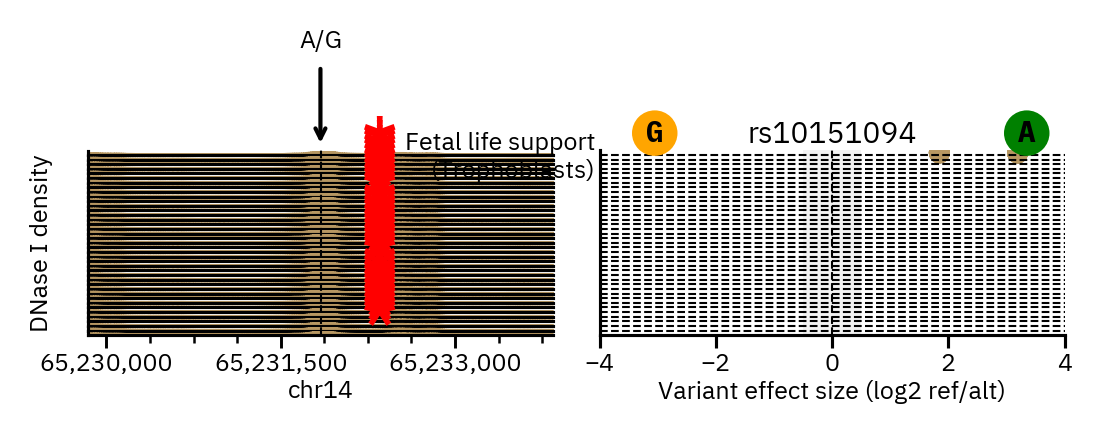

In [284]:
#Stromal/Brain, Discordant, ATF2 <-> NFIX
vid = "rs10151094"

variant_data = preprocessor.get_variant_data(vid, components)
axes, gs = plot_variant(variant_data)
axes[1].set_xlim(-4, 4)

In [21]:
eval_dataset

,ref_counts,total_counts,sample_id,chrom,pos,bad_score,lfc,pred_lfc
0,15.0,32.0,AG10031,chr1,23559582,1.0,-0.123233,-0.414186
1,17.0,32.0,AG10031,chr1,30719457,1.0,0.123233,0.128996
2,17.0,31.0,AG10031,chr1,146037986,2.0,-0.339548,0.062472
3,9.0,50.0,AG10031,chr1,204507123,3.0,-0.411124,-0.037123
4,27.0,46.0,AG10031,chr1,234499246,2.5,-0.554565,-0.165226
...,...,...,...,...,...,...,...,...
784379,12.0,27.0,AG4009,chr17,47279416,1.0,-0.219683,-0.318387
784380,13.0,23.0,AG4009,chr3,143001506,1.0,0.258282,0.171577
784381,13.0,25.0,AG4009,chr5,75337189,1.0,0.078810,-0.002990
784382,9.0,22.0,AG4009,chr5,172771497,1.0,-0.361942,-0.113328


In [23]:
len(records) == len(y_hat_all)

True

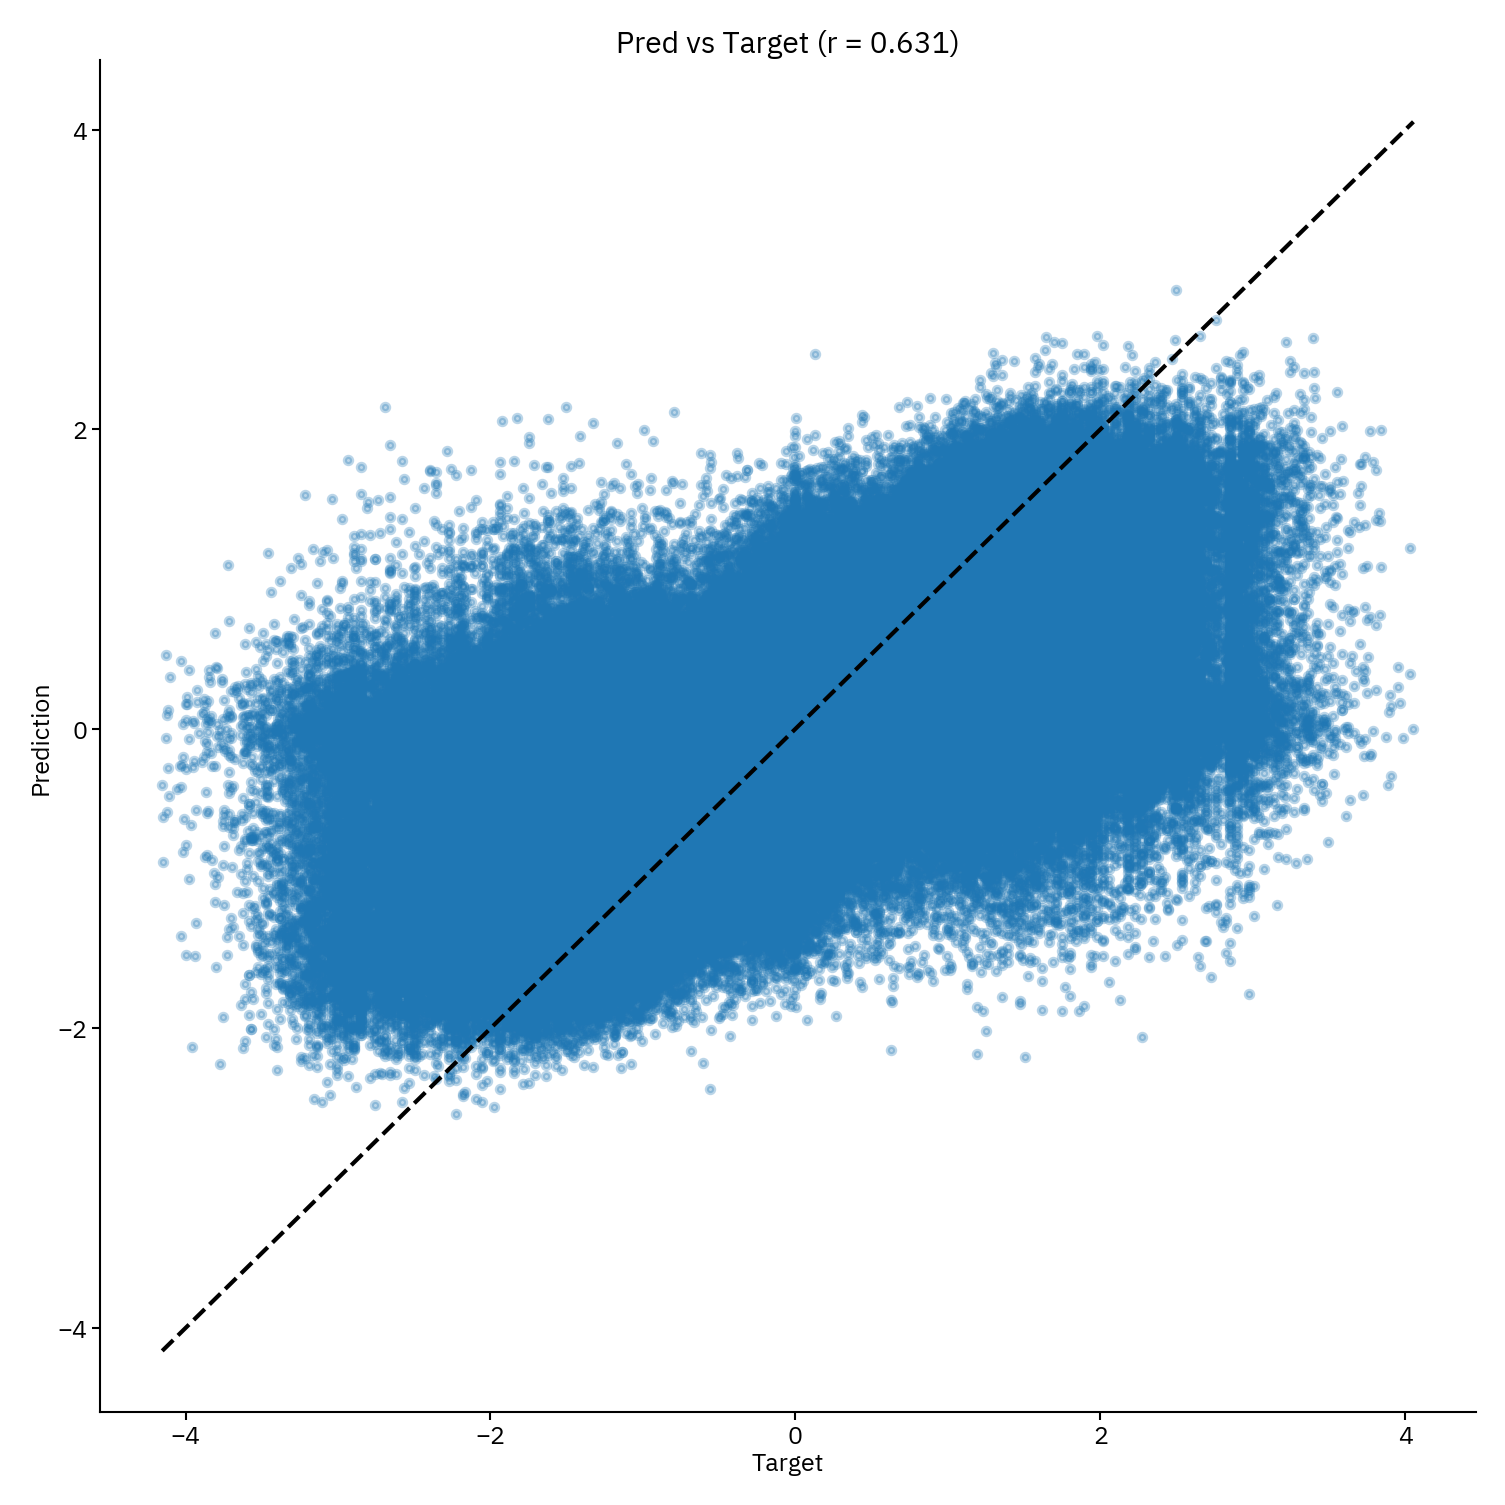

In [25]:
plt.figure(figsize=(5, 5))
all_targets = eval_dataset['lfc'].values
all_preds = eval_dataset['pred_lfc'].values
plt.scatter(all_target, all_preds, s=3, alpha=0.3)

# diagonal line
lims = [
    min(all_targets.min(), all_preds.min()),
    max(all_targets.max(), all_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_targets, all_preds)

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title(f"Pred vs Target (r = {r:.3f})")
plt.tight_layout()
plt.show()
